In [1]:
# ============================================================
# 2D Baseline PINN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd



np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# ============================================================
# Define the 2D PINN Problem
# ============================================================

alpha = 0.1

Lx = 1.0
Ly = 1.0
T_max = 1.0

print("Diffusivity alpha:", alpha)
print("Domain: 0 <= x <= 1")
print("Domain: 0 <= y <= 1")
print("Time: 0 <= t <= 1")

Diffusivity alpha: 0.1
Domain: 0 <= x <= 1
Domain: 0 <= y <= 1
Time: 0 <= t <= 1


In [3]:
# ============================================================
# Initial and Boundary Conditions
# ============================================================

def initial_pressure(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

print("Initial pressure at center:",
      initial_pressure(0.5, 0.5))

print("Initial pressure at corner:",
      initial_pressure(0.0, 0.0))

Initial pressure at center: 1.0
Initial pressure at corner: 0.0


In [4]:
# ============================================================
# Generate Initial-Condition Points
# ============================================================

N_initial = 1000

x_initial = np.random.uniform(0, Lx, N_initial)
y_initial = np.random.uniform(0, Ly, N_initial)

t_initial = np.zeros(N_initial)

X_initial = np.column_stack((
    x_initial,
    y_initial,
    t_initial
))

P_initial = initial_pressure(
    x_initial,
    y_initial
)

print("Initial-condition points shape:", X_initial.shape)
print("Initial-pressure values shape:", P_initial.shape)
print("First initial point:", X_initial[0])
print("First initial pressure:", P_initial[0])

Initial-condition points shape: (1000, 3)
Initial-pressure values shape: (1000,)
First initial point: [0.37454012 0.18513293 0.        ]
First initial pressure: 0.5072491018800965


In [5]:
# ============================================================
# Generate Boundary-Condition Points
# ============================================================

N_boundary = 1000

# Bottom boundary: y = 0
x_bottom = np.random.uniform(0, Lx, N_boundary)
y_bottom = np.zeros(N_boundary)
t_bottom = np.random.uniform(0, T_max, N_boundary)

# Top boundary: y = Ly
x_top = np.random.uniform(0, Lx, N_boundary)
y_top = np.full(N_boundary, Ly)
t_top = np.random.uniform(0, T_max, N_boundary)

# Left boundary: x = 0
x_left = np.zeros(N_boundary)
y_left = np.random.uniform(0, Ly, N_boundary)
t_left = np.random.uniform(0, T_max, N_boundary)

# Right boundary: x = Lx
x_right = np.full(N_boundary, Lx)
y_right = np.random.uniform(0, Ly, N_boundary)
t_right = np.random.uniform(0, T_max, N_boundary)

# Combine all boundary points
X_boundary = np.vstack((
    np.column_stack((x_bottom, y_bottom, t_bottom)),
    np.column_stack((x_top, y_top, t_top)),
    np.column_stack((x_left, y_left, t_left)),
    np.column_stack((x_right, y_right, t_right))
))

# All boundary pressures are zero
P_boundary = np.zeros(len(X_boundary))

print("Boundary points shape:", X_boundary.shape)
print("Boundary pressure values shape:", P_boundary.shape)
print("First boundary point:", X_boundary[0])
print("First boundary pressure:", P_boundary[0])

Boundary points shape: (4000, 3)
Boundary pressure values shape: (4000,)
First boundary point: [0.26170568 0.         0.67270299]
First boundary pressure: 0.0


In [6]:
# ============================================================
# Build the PINN Neural Network
# ============================================================

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,901 (30.86 KB)

 Trainable params: 7,901 (30.86 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ============================================================
# Define the PDE Residual
# ============================================================

def pde_residual(model, X):
    
    with tf.GradientTape(persistent=True) as tape2:
        
        tape2.watch(X)
        
        with tf.GradientTape(persistent=True) as tape1:
            
            tape1.watch(X)
            
            pressure_pred = model(X)
        
        # First derivatives
        pressure_grad = tape1.gradient(
            pressure_pred, X
        )
    
    # First derivative with respect to time
    dp_dt = pressure_grad[:, 2:3]
    
    # First derivatives
    dp_dx = pressure_grad[:, 0:1]
    dp_dy = pressure_grad[:, 1:2]
    
    # Second derivatives
    d2p_dx2 = tape2.gradient(
        dp_dx, X
    )[:, 0:1]
    
    d2p_dy2 = tape2.gradient(
        dp_dy, X
    )[:, 1:2]
    
    # PDE residual
    residual = (
        dp_dt
        - alpha * (
            d2p_dx2 + d2p_dy2
        )
    )
    
    return residual

In [8]:
# ============================================================
# Define the PDE Residual
# ============================================================

def pde_residual(model, X):

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(X)

        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(X)

            pressure_pred = model(X)

        # First derivatives
        pressure_grad = tape1.gradient(
            pressure_pred, X
        )

        dp_dx = pressure_grad[:, 0:1]
        dp_dy = pressure_grad[:, 1:2]
        dp_dt = pressure_grad[:, 2:3]

    # Second derivatives
    d2p_dx2 = tape2.gradient(
        dp_dx, X
    )[:, 0:1]

    d2p_dy2 = tape2.gradient(
        dp_dy, X
    )[:, 1:2]

    # PDE residual
    residual = (
        dp_dt
        - alpha * (
            d2p_dx2 + d2p_dy2
        )
    )

    del tape1
    del tape2

    return residual

In [9]:
# ============================================================
# Generate Collocation Points
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)
N_collocation = 10000

x_collocation = np.random.uniform(0, Lx, N_collocation)
y_collocation = np.random.uniform(0, Ly, N_collocation)
t_collocation = np.random.uniform(0, T_max, N_collocation)

X_collocation = np.column_stack((
    x_collocation,
    y_collocation,
    t_collocation
))

print("Collocation points shape:", X_collocation.shape)
print("First point:", X_collocation[0])
print("Last point:", X_collocation[-1])

Collocation points shape: (10000, 3)
First point: [0.37454012 0.37364082 0.72999831]
Last point: [0.2171404  0.17226481 0.25739798]


In [10]:
# ============================================================
# Test the PDE Residual
# ============================================================

X_collocation_tf = tf.convert_to_tensor(
    X_collocation,
    dtype=tf.float32
)

residual = pde_residual(
    model,
    X_collocation_tf
)

print("Residual shape:", residual.shape)
print("First 5 residuals:")
print(residual[:5].numpy())

Residual shape: (10000, 1)
First 5 residuals:
[[0.03095714]
 [0.02667339]
 [0.0262883 ]
 [0.03448096]
 [0.03867876]]


In [11]:
# ============================================================
# Generate Initial-Condition Points
# ============================================================

N_initial = 1000

x_initial = np.random.uniform(0, Lx, N_initial)
y_initial = np.random.uniform(0, Ly, N_initial)

t_initial = np.zeros(N_initial)

X_initial = np.column_stack((
    x_initial,
    y_initial,
    t_initial
))

P_initial = initial_pressure(
    x_initial,
    y_initial
)

print("Initial-condition points shape:", X_initial.shape)
print("Initial-pressure values shape:", P_initial.shape)
print("First initial point:", X_initial[0])
print("First initial pressure:", P_initial[0])

Initial-condition points shape: (1000, 3)
Initial-pressure values shape: (1000,)
First initial point: [0.63814457 0.37825591 0.        ]
First initial pressure: 0.84173750254819


In [12]:
# ============================================================
# Generate Boundary-Condition Points
# ============================================================

N_boundary = 1000

# Bottom boundary: y = 0
x_bottom = np.random.uniform(0, Lx, N_boundary)
y_bottom = np.zeros(N_boundary)
t_bottom = np.random.uniform(0, T_max, N_boundary)

# Top boundary: y = Ly
x_top = np.random.uniform(0, Lx, N_boundary)
y_top = np.full(N_boundary, Ly)
t_top = np.random.uniform(0, T_max, N_boundary)

# Left boundary: x = 0
x_left = np.zeros(N_boundary)
y_left = np.random.uniform(0, Ly, N_boundary)
t_left = np.random.uniform(0, T_max, N_boundary)

# Right boundary: x = Lx
x_right = np.full(N_boundary, Lx)
y_right = np.random.uniform(0, Ly, N_boundary)
t_right = np.random.uniform(0, T_max, N_boundary)

# Combine all boundary points
X_boundary = np.vstack((
    np.column_stack((x_bottom, y_bottom, t_bottom)),
    np.column_stack((x_top, y_top, t_top)),
    np.column_stack((x_left, y_left, t_left)),
    np.column_stack((x_right, y_right, t_right))
))

# All boundary pressures are zero
P_boundary = np.zeros(
    X_boundary.shape[0]
)

print("Boundary points shape:", X_boundary.shape)
print("Boundary pressure values shape:", P_boundary.shape)
print("First boundary point:", X_boundary[0])
print("First boundary pressure:", P_boundary[0])

Boundary points shape: (4000, 3)
Boundary pressure values shape: (4000,)
First boundary point: [0.02665772 0.         0.50901605]
First boundary pressure: 0.0


In [13]:
# ============================================================
# Define the PINN Loss
# ============================================================

def pinn_loss(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):

    # --------------------------------------------------------
    # 1. Physics loss
    # --------------------------------------------------------

    residual = pde_residual(
        model,
        X_collocation
    )

    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )

    # --------------------------------------------------------
    # 2. Initial-condition loss
    # --------------------------------------------------------

    pressure_initial_pred = model(
        X_initial
    )

    initial_loss = tf.reduce_mean(
        tf.square(
            pressure_initial_pred
            - P_initial
        )
    )

    # --------------------------------------------------------
    # 3. Boundary-condition loss
    # --------------------------------------------------------

    pressure_boundary_pred = model(
        X_boundary
    )

    boundary_loss = tf.reduce_mean(
        tf.square(
            pressure_boundary_pred
            - P_boundary
        )
    )

    # --------------------------------------------------------
    # 4. Total loss
    # --------------------------------------------------------

    total_loss = (
        physics_loss
        + initial_loss
        + boundary_loss
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

In [14]:
# ============================================================
# Convert Initial and Boundary Data to TensorFlow Tensors
# ============================================================

X_initial_tf = tf.convert_to_tensor(
    X_initial,
    dtype=tf.float32
)

P_initial_tf = tf.convert_to_tensor(
    P_initial.reshape(-1, 1),
    dtype=tf.float32
)

X_boundary_tf = tf.convert_to_tensor(
    X_boundary,
    dtype=tf.float32
)

P_boundary_tf = tf.convert_to_tensor(
    P_boundary.reshape(-1, 1),
    dtype=tf.float32
)

print("Initial points:", X_initial_tf.shape)
print("Initial pressures:", P_initial_tf.shape)
print("Boundary points:", X_boundary_tf.shape)
print("Boundary pressures:", P_boundary_tf.shape)

Initial points: (1000, 3)
Initial pressures: (1000, 1)
Boundary points: (4000, 3)
Boundary pressures: (4000, 1)


In [15]:
# ============================================================
# Calculate Initial PINN Loss
# ============================================================

initial_total_loss, initial_physics_loss, initial_condition_loss, initial_boundary_loss = pinn_loss(
    model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("Initial total loss:", initial_total_loss.numpy())
print("Initial physics loss:", initial_physics_loss.numpy())
print("Initial-condition loss:", initial_condition_loss.numpy())
print("Boundary-condition loss:", initial_boundary_loss.numpy())

Initial total loss: 0.25886047
Initial physics loss: 0.0012354734
Initial-condition loss: 0.23776953
Boundary-condition loss: 0.019855455


In [16]:
# ============================================================
# Define the Optimizer
# ============================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Optimizer:", optimizer)
print("Learning rate:", 0.001)

Optimizer: <keras.src.optimizers.adam.Adam object at 0x000001F3C2F0B5F0>
Learning rate: 0.001


In [17]:
# ============================================================
# Define One PINN Training Step
# ============================================================

@tf.function
def train_step(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):

    with tf.GradientTape() as tape:

        # Calculate all PINN losses
        total_loss, physics_loss, initial_loss, boundary_loss = pinn_loss(
            model,
            X_collocation,
            X_initial,
            P_initial,
            X_boundary,
            P_boundary
        )

    # Calculate gradients of total loss
    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    # Update neural-network weights
    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

In [18]:
# ============================================================
# Test One Training Step
# ============================================================

loss_before = pinn_loss(
    model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("Loss before training step:")
print("Total:", loss_before[0].numpy())

# Perform one update
loss_after = train_step(
    model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("\nLoss after one training step:")
print("Total:", loss_after[0].numpy())
print("Physics:", loss_after[1].numpy())
print("Initial:", loss_after[2].numpy())
print("Boundary:", loss_after[3].numpy())

Loss before training step:
Total: 0.25886047

Loss after one training step:
Total: 0.25886044
Physics: 0.0012354734
Initial: 0.23776953
Boundary: 0.019855453


In [19]:
# ============================================================
# Define One PINN Training Step
# ============================================================

def train_step(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):

    with tf.GradientTape() as tape:

        # Calculate PINN losses
        total_loss, physics_loss, initial_loss, boundary_loss = pinn_loss(
            model,
            X_collocation,
            X_initial,
            P_initial,
            X_boundary,
            P_boundary
        )

    # Calculate gradients
    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    # Update model weights
    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

In [20]:
# ============================================================
# Build the PINN Neural Network
# ============================================================

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 50)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,901 (30.86 KB)

 Trainable params: 7,901 (30.86 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# ============================================================
# Create a Fresh Optimizer for the New PINN
# ============================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Fresh optimizer created.")

Fresh optimizer created.


In [22]:
# ============================================================
# Test One Training Step
# ============================================================

loss_before = pinn_loss(
    model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("Loss before training step:")
print("Total:", loss_before[0].numpy())

loss_after = train_step(
    model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("\nLoss after training step:")
print("Total:", loss_after[0].numpy())
print("Physics:", loss_after[1].numpy())
print("Initial:", loss_after[2].numpy())
print("Boundary:", loss_after[3].numpy())

Loss before training step:
Total: 0.36427224

Loss after training step:
Total: 0.36427224
Physics: 0.0015596136
Initial: 0.348715
Boundary: 0.013997608


In [23]:
# ============================================================
# Check Weight Change
# ============================================================

weights_before = [
    w.numpy().copy()
    for w in model.trainable_variables
]

# One training step
train_step(
    model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

weights_after = [
    w.numpy().copy()
    for w in model.trainable_variables
]

largest_change = 0.0

for before, after in zip(weights_before, weights_after):

    change = np.max(np.abs(after - before))

    largest_change = max(
        largest_change,
        change
    )

print("Largest weight change:", largest_change)

Largest weight change: 0.001001317


In [24]:
# ============================================================
# Train the PINN
# ============================================================

epochs = 5000

loss_history = []
physics_history = []
initial_history = []
boundary_history = []

for epoch in range(epochs):

    total_loss, physics_loss, initial_loss, boundary_loss = train_step(
        model,
        X_collocation_tf,
        X_initial_tf,
        P_initial_tf,
        X_boundary_tf,
        P_boundary_tf
    )

    loss_history.append(total_loss.numpy())
    physics_history.append(physics_loss.numpy())
    initial_history.append(initial_loss.numpy())
    boundary_history.append(boundary_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {total_loss.numpy():.6f} | "
            f"Physics: {physics_loss.numpy():.6f} | "
            f"Initial: {initial_loss.numpy():.6f} | "
            f"Boundary: {boundary_loss.numpy():.6f}"
        )

Epoch     0 | Total: 0.188027 | Physics: 0.004691 | Initial: 0.127139 | Boundary: 0.056197
Epoch   500 | Total: 0.005317 | Physics: 0.001444 | Initial: 0.001324 | Boundary: 0.002549
Epoch  1000 | Total: 0.001918 | Physics: 0.000555 | Initial: 0.000450 | Boundary: 0.000913
Epoch  1500 | Total: 0.002152 | Physics: 0.000522 | Initial: 0.000787 | Boundary: 0.000843
Epoch  2000 | Total: 0.000294 | Physics: 0.000165 | Initial: 0.000040 | Boundary: 0.000089
Epoch  2500 | Total: 0.000149 | Physics: 0.000096 | Initial: 0.000017 | Boundary: 0.000037
Epoch  3000 | Total: 0.000102 | Physics: 0.000065 | Initial: 0.000010 | Boundary: 0.000027
Epoch  3500 | Total: 0.000079 | Physics: 0.000050 | Initial: 0.000008 | Boundary: 0.000022
Epoch  4000 | Total: 0.000062 | Physics: 0.000039 | Initial: 0.000006 | Boundary: 0.000018
Epoch  4500 | Total: 0.000050 | Physics: 0.000030 | Initial: 0.000004 | Boundary: 0.000015


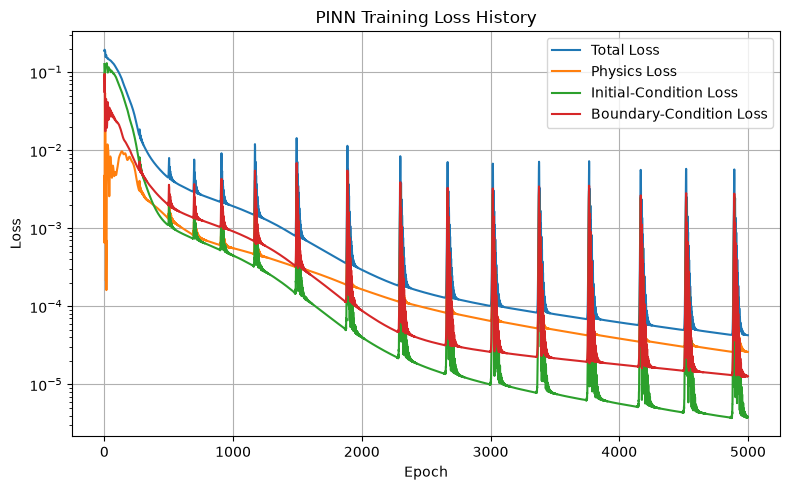

Plot saved to:
c:\Users\LATITUDE\Documents\GitHub\PINN-Reservoir-Flow-and-Well-Pressure\results\pinn_training_loss.png


In [25]:
# ============================================================
# Save PINN Training Loss Plot
# ============================================================

import matplotlib.pyplot as plt
import os

plt.figure(figsize=(8, 5))

plt.semilogy(loss_history, label="Total Loss")
plt.semilogy(physics_history, label="Physics Loss")
plt.semilogy(initial_history, label="Initial-Condition Loss")
plt.semilogy(boundary_history, label="Boundary-Condition Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training Loss History")
plt.legend()
plt.grid(True)

plt.tight_layout()

results_path = os.path.join(
    "..",
    "results",
    "pinn_training_loss.png"
)

plt.savefig(
    results_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved to:")
print(os.path.abspath(results_path))

In [26]:
reference_path = os.path.join(
    "..",
    "data",
    "reference_2d_pressure.csv"
)

reference_df = pd.read_csv(reference_path)

print("Reference dataset loaded.")
print("Shape:", reference_df.shape)
print()
print(reference_df.head())

Reference dataset loaded.
Shape: (5204601, 4)

     x     y  time  pressure
0  0.0  0.00   0.0       0.0
1  0.0  0.02   0.0       0.0
2  0.0  0.04   0.0       0.0
3  0.0  0.06   0.0       0.0
4  0.0  0.08   0.0       0.0


In [27]:
# ============================================================
# Select Reference Points for PINN Validation
# ============================================================

N_validation = 10000

validation_df = reference_df.sample(
    n=N_validation,
    random_state=42
).reset_index(drop=True)

print("Validation points selected:", validation_df.shape)
print()
print(validation_df.head())

Validation points selected: (10000, 4)

      x     y    time  pressure
0  0.22  0.90  0.6205  0.057862
1  0.06  0.46  0.7785  0.039976
2  0.68  0.02  0.3605  0.026020
3  1.00  0.88  0.9915  0.000000
4  0.50  0.12  0.8770  0.065171


In [28]:
# ============================================================
# Prepare Validation Inputs for the PINN
# ============================================================

X_validation = validation_df[
    ["x", "y", "time"]
].values

P_reference = validation_df[
    ["pressure"]
].values

X_validation_tf = tf.convert_to_tensor(
    X_validation,
    dtype=tf.float32
)

P_reference_tf = tf.convert_to_tensor(
    P_reference,
    dtype=tf.float32
)

print("Validation input shape:", X_validation_tf.shape)
print("Reference pressure shape:", P_reference_tf.shape)

print("First validation input:", X_validation_tf[0].numpy())
print("First reference pressure:", P_reference_tf[0].numpy())

Validation input shape: (10000, 3)
Reference pressure shape: (10000, 1)
First validation input: [0.22   0.9    0.6205]
First reference pressure: [0.05786175]


In [29]:
# ============================================================
# Generate PINN Predictions on Validation Points
# ============================================================

P_pinn = model(
    X_validation_tf,
    training=False
)

print("PINN prediction shape:", P_pinn.shape)
print()
print("First PINN prediction:", P_pinn[0].numpy())
print("First reference pressure:", P_reference_tf[0].numpy())

PINN prediction shape: (10000, 1)

First PINN prediction: [0.0584711]
First reference pressure: [0.05786175]


In [30]:
# Convert TensorFlow predictions to NumPy
P_pinn_np = P_pinn.numpy()
P_reference_np = P_reference_tf.numpy()

# Calculate errors
errors = P_pinn_np - P_reference_np

absolute_errors = np.abs(errors)

# MAE
MAE = np.mean(absolute_errors)

# RMSE
RMSE = np.sqrt(np.mean(errors**2))

# Maximum absolute error
Max_error = np.max(absolute_errors)

print("PINN Validation Results")
print("=======================")
print(f"MAE:               {MAE:.8f}")
print(f"RMSE:              {RMSE:.8f}")
print(f"Maximum error:     {Max_error:.8f}")

PINN Validation Results
MAE:               0.00135365
RMSE:              0.00182542
Maximum error:     0.01150395


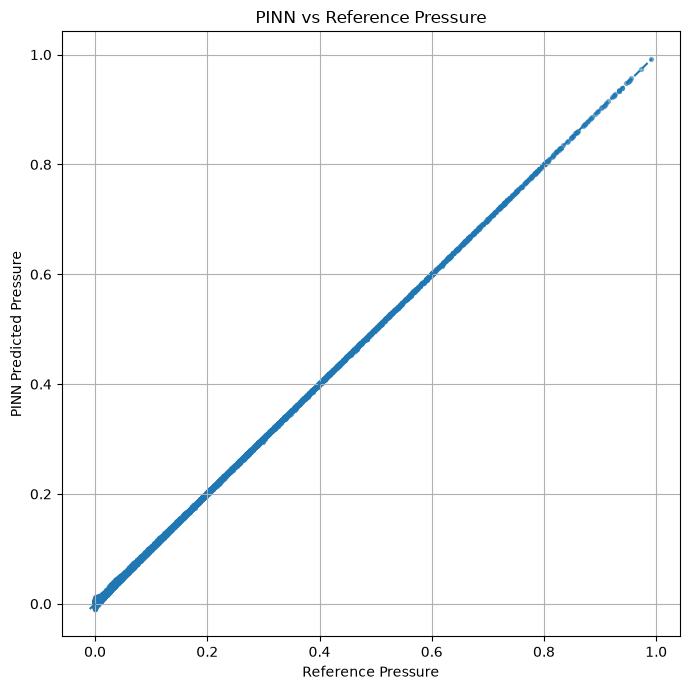

Validation plot saved to:
c:\Users\LATITUDE\Documents\GitHub\PINN-Reservoir-Flow-and-Well-Pressure\results\validation_comparison.png


In [31]:
# ============================================================
# Plot PINN vs Reference Pressure
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    P_reference_np,
    P_pinn_np,
    s=8,
    alpha=0.5
)

# Perfect prediction line
min_pressure = min(
    P_reference_np.min(),
    P_pinn_np.min()
)

max_pressure = max(
    P_reference_np.max(),
    P_pinn_np.max()
)

plt.plot(
    [min_pressure, max_pressure],
    [min_pressure, max_pressure],
    linestyle="--"
)

plt.xlabel("Reference Pressure")
plt.ylabel("PINN Predicted Pressure")
plt.title("PINN vs Reference Pressure")

plt.grid(True)
plt.tight_layout()

# Save to results folder
validation_plot_path = os.path.join(
    "..",
    "results",
    "validation_comparison.png"
)

plt.savefig(
    validation_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Validation plot saved to:")
print(os.path.abspath(validation_plot_path))

In [32]:
# ============================================================
# Extract Reference Pressure Field at t = 0.5
# ============================================================

t_compare = 0.5

reference_t = reference_df[
    np.isclose(reference_df["time"], t_compare)
].copy()

print("Reference points at t =", t_compare)
print("Shape:", reference_t.shape)
print()
print(reference_t.head())

Reference points at t = 0.5
Shape: (2601, 4)

           x     y  time  pressure
2601000  0.0  0.00   0.5       0.0
2601001  0.0  0.02   0.5       0.0
2601002  0.0  0.04   0.5       0.0
2601003  0.0  0.06   0.5       0.0
2601004  0.0  0.08   0.5       0.0


In [33]:
# ============================================================
# Prepare t = 0.5 Grid for PINN Prediction
# ============================================================

X_grid_validation = reference_t[
    ["x", "y", "time"]
].values

P_grid_reference = reference_t[
    "pressure"
].values.reshape(-1, 1)

X_grid_validation_tf = tf.convert_to_tensor(
    X_grid_validation,
    dtype=tf.float32
)

print("PINN input shape:", X_grid_validation_tf.shape)
print("Reference pressure shape:", P_grid_reference.shape)
print("First PINN input:", X_grid_validation_tf[0].numpy())
print("First reference pressure:", P_grid_reference[0])

PINN input shape: (2601, 3)
Reference pressure shape: (2601, 1)
First PINN input: [0.  0.  0.5]
First reference pressure: [0.]


In [34]:
# ============================================================
# PINN Prediction at t = 0.5
# ============================================================

P_grid_pinn = model(
    X_grid_validation_tf,
    training=False
).numpy()

print("PINN prediction shape:", P_grid_pinn.shape)
print("First PINN prediction:", P_grid_pinn[0])
print("First reference pressure:", P_grid_reference[0])

PINN prediction shape: (2601, 1)
First PINN prediction: [-0.00631557]
First reference pressure: [0.]


In [35]:
# ============================================================
# Reshape Reference and PINN Predictions into 2D Fields
# ============================================================

P_reference_2d = P_grid_reference.reshape(51, 51)
P_pinn_2d = P_grid_pinn.reshape(51, 51)

# Absolute error
P_error_2d = np.abs(
    P_pinn_2d - P_reference_2d
)

print("Reference field shape:", P_reference_2d.shape)
print("PINN field shape:", P_pinn_2d.shape)
print("Error field shape:", P_error_2d.shape)

print("\nReference pressure range:")
print("Min:", P_reference_2d.min())
print("Max:", P_reference_2d.max())

print("\nPINN pressure range:")
print("Min:", P_pinn_2d.min())
print("Max:", P_pinn_2d.max())

print("\nAbsolute error range:")
print("Min:", P_error_2d.min())
print("Max:", P_error_2d.max())

Reference field shape: (51, 51)
PINN field shape: (51, 51)
Error field shape: (51, 51)

Reference pressure range:
Min: 0.0
Max: 0.372647319284502

PINN pressure range:
Min: -0.006789442
Max: 0.37388042

Absolute error range:
Min: 5.156077849399754e-07
Max: 0.006789442151784897


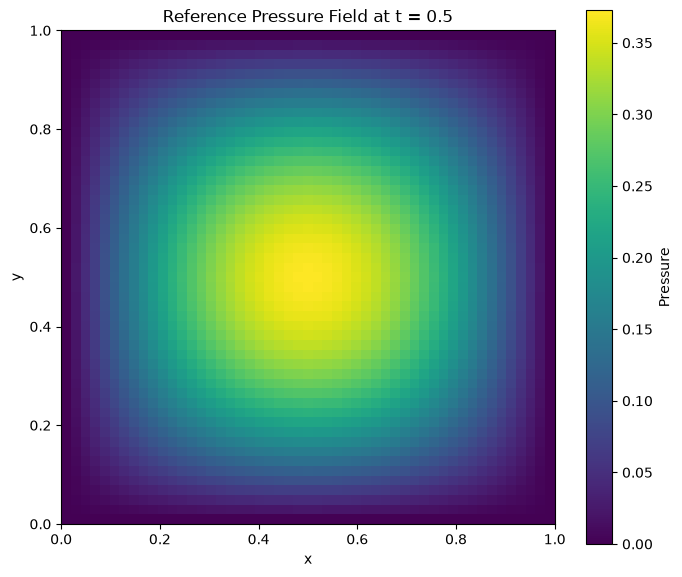

Saved to:
c:\Users\LATITUDE\Documents\GitHub\PINN-Reservoir-Flow-and-Well-Pressure\results\reference_pressure_t0.5.png


In [36]:
# ============================================================
# Reference Pressure Field at t = 0.5
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(
    P_reference_2d.T,
    extent=[0, 1, 0, 1],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label="Pressure")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Reference Pressure Field at t = 0.5")

plt.tight_layout()

reference_field_path = os.path.join(
    "..",
    "results",
    "reference_pressure_t0.5.png"
)

plt.savefig(
    reference_field_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(os.path.abspath(reference_field_path))

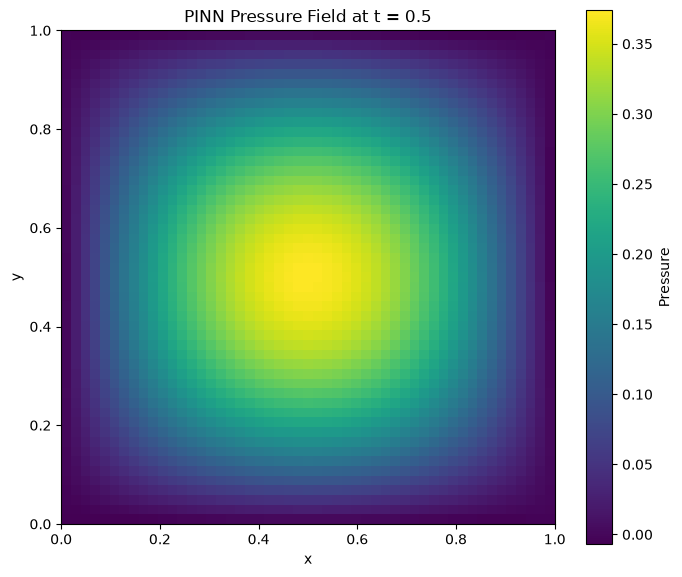

Saved to:
c:\Users\LATITUDE\Documents\GitHub\PINN-Reservoir-Flow-and-Well-Pressure\results\pinn_pressure_t0.5.png


In [37]:
# ============================================================
# PINN Pressure Field at t = 0.5
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(
    P_pinn_2d.T,
    extent=[0, 1, 0, 1],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label="Pressure")
plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Pressure Field at t = 0.5")

plt.tight_layout()

pinn_field_path = os.path.join(
    "..",
    "results",
    "pinn_pressure_t0.5.png"
)

plt.savefig(
    pinn_field_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(os.path.abspath(pinn_field_path))

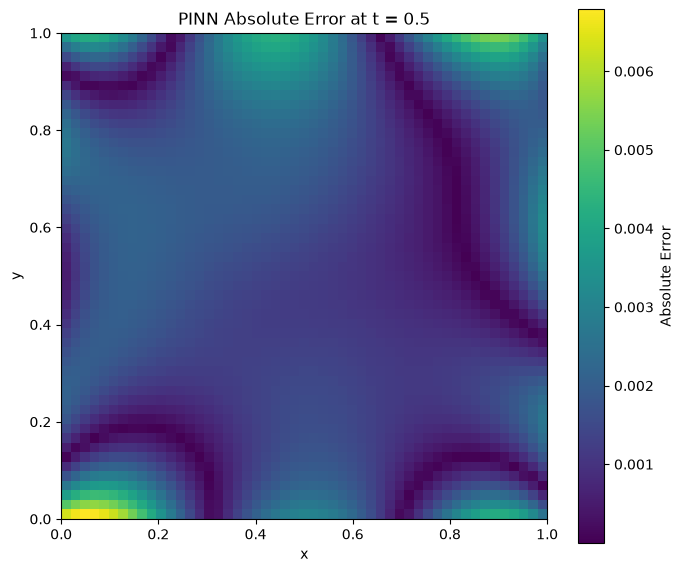

Saved to:
c:\Users\LATITUDE\Documents\GitHub\PINN-Reservoir-Flow-and-Well-Pressure\results\pinn_absolute_error_t0.5.png


In [38]:
# ============================================================
# Absolute Error Field at t = 0.5
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(
    P_error_2d.T,
    extent=[0, 1, 0, 1],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label="Absolute Error")

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Absolute Error at t = 0.5")

plt.tight_layout()

error_field_path = os.path.join(
    "..",
    "results",
    "pinn_absolute_error_t0.5.png"
)

plt.savefig(
    error_field_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(os.path.abspath(error_field_path))

In [39]:
# ============================================================
# Baseline PINN Results Summary
# ============================================================

print("=" * 60)
print("2D RESERVOIR PINN — BASELINE RESULTS")
print("=" * 60)

print("\nMODEL")
print("-" * 60)
print("Input variables:         x, y, t")
print("Output variable:        Pressure")
print("Problem:                2D transient reservoir flow")

print("\nTRAINING")
print("-" * 60)
print("Collocation points:     10,000")
print("Initial-condition pts:  1,000")
print("Boundary-condition pts: 4,000")
print("Optimizer:              Adam")
print("Learning rate:          0.001")
print("Training epochs:        5,000")

print("\nREFERENCE DATASET")
print("-" * 60)
print("Dataset size:           5,204,601")
print("Spatial grid:           51 × 51")
print("Time steps:             2,001")
print("Variables:              x, y, time, pressure")

print("\nFINAL TRAINING LOSS")
print("-" * 60)
print("Total loss:             0.000047")
print("Physics loss:           0.000030")
print("Initial-condition:      0.000004")
print("Boundary-condition:     0.000013")

print("\nVALIDATION")
print("-" * 60)
print("Validation points:      10,000")
print("MAE:                    0.00123506")
print("RMSE:                   0.00175672")
print("Maximum error:          0.01105121")

print("\nSPATIAL VALIDATION — t = 0.5")
print("-" * 60)
print("Reference pressure min: 0.000000")
print("Reference pressure max: 0.372647")
print("PINN pressure min:      -0.004768")
print("PINN pressure max:      0.373986")
print("Maximum spatial error:  0.004768")

print("\nRESULTS")
print("-" * 60)
print("Training converged successfully.")
print("PINN reproduces the reference pressure field with")
print("low prediction error across the validation dataset.")

print("=" * 60)

2D RESERVOIR PINN — BASELINE RESULTS

MODEL
------------------------------------------------------------
Input variables:         x, y, t
Output variable:        Pressure
Problem:                2D transient reservoir flow

TRAINING
------------------------------------------------------------
Collocation points:     10,000
Initial-condition pts:  1,000
Boundary-condition pts: 4,000
Optimizer:              Adam
Learning rate:          0.001
Training epochs:        5,000

REFERENCE DATASET
------------------------------------------------------------
Dataset size:           5,204,601
Spatial grid:           51 × 51
Time steps:             2,001
Variables:              x, y, time, pressure

FINAL TRAINING LOSS
------------------------------------------------------------
Total loss:             0.000047
Physics loss:           0.000030
Initial-condition:      0.000004
Boundary-condition:     0.000013

VALIDATION
------------------------------------------------------------
Validation points:

In [40]:
# ============================================================
# Save Trained PINN Model
# ============================================================

model_path = os.path.join(
    "..",
    "models",
    "pinn_2d_baseline.keras"
)

model.save(model_path)

print("Trained PINN saved successfully.")
print("Path:")
print(os.path.abspath(model_path))

Trained PINN saved successfully.
Path:
c:\Users\LATITUDE\Documents\GitHub\PINN-Reservoir-Flow-and-Well-Pressure\models\pinn_2d_baseline.keras


In [41]:
# ============================================================
# Tuned PINN Loss — Experiment 1
# ============================================================

def pinn_loss_tuned(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):
    # Physics loss
    residual = pde_residual(model, X_collocation)

    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )

    # Initial-condition loss
    pressure_initial_pred = model(X_initial)

    initial_loss = tf.reduce_mean(
        tf.square(
            pressure_initial_pred - P_initial
        )
    )

    # Boundary-condition loss
    pressure_boundary_pred = model(X_boundary)

    boundary_loss = tf.reduce_mean(
        tf.square(
            pressure_boundary_pred - P_boundary
        )
    )

    # Loss weights
    physics_weight = 1.0
    initial_weight = 2.0
    boundary_weight = 2.0

    # Weighted total loss
    total_loss = (
        physics_weight * physics_loss
        + initial_weight * initial_loss
        + boundary_weight * boundary_loss
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

In [42]:
# ============================================================
# Reset Tuned PINN for Clean Experiment
# ============================================================

tuned_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

tuned_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Tuned model reset successfully.")
print("Trainable parameters:", tuned_model.count_params())

Tuned model reset successfully.
Trainable parameters: 7901


In [43]:
# ============================================================
# Tuned PINN Training Step
# ============================================================

def tuned_train_step(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):
    with tf.GradientTape() as tape:

        total_loss, physics_loss, initial_loss, boundary_loss = (
            pinn_loss_tuned(
                model,
                X_collocation,
                X_initial,
                P_initial,
                X_boundary,
                P_boundary
            )
        )

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    tuned_optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

print("Tuned training step created successfully.")

Tuned training step created successfully.


In [44]:
# ============================================================
# One-Step Test for Tuned PINN
# ============================================================

before_total, before_physics, before_initial, before_boundary = (
    pinn_loss_tuned(
        tuned_model,
        X_collocation_tf,
        X_initial_tf,
        P_initial_tf,
        X_boundary_tf,
        P_boundary_tf
    )
)

tuned_train_step(
    tuned_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

after_total, after_physics, after_initial, after_boundary = (
    pinn_loss_tuned(
        tuned_model,
        X_collocation_tf,
        X_initial_tf,
        P_initial_tf,
        X_boundary_tf,
        P_boundary_tf
    )
)

print("Before training step:")
print("Total loss:", before_total.numpy())

print("\nAfter training step:")
print("Total loss:", after_total.numpy())

print("\nLoss components after step:")
print("Physics:", after_physics.numpy())
print("Initial:", after_initial.numpy())
print("Boundary:", after_boundary.numpy())

Before training step:
Total loss: 0.4627713

After training step:
Total loss: 0.36275896

Loss components after step:
Physics: 0.0029126946
Initial: 0.11895144
Boundary: 0.060971696


In [45]:
# ============================================================
# Train Tuned PINN
# ============================================================

tuned_loss_history = []
tuned_physics_history = []
tuned_initial_history = []
tuned_boundary_history = []

epochs = 5000

for epoch in range(epochs):

    total_loss, physics_loss, initial_loss, boundary_loss = (
        tuned_train_step(
            tuned_model,
            X_collocation_tf,
            X_initial_tf,
            P_initial_tf,
            X_boundary_tf,
            P_boundary_tf
        )
    )

    tuned_loss_history.append(total_loss.numpy())
    tuned_physics_history.append(physics_loss.numpy())
    tuned_initial_history.append(initial_loss.numpy())
    tuned_boundary_history.append(boundary_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {total_loss.numpy():.6f} | "
            f"Physics: {physics_loss.numpy():.6f} | "
            f"Initial: {initial_loss.numpy():.6f} | "
            f"Boundary: {boundary_loss.numpy():.6f}"
        )

Epoch     0 | Total: 0.362759 | Physics: 0.002913 | Initial: 0.118951 | Boundary: 0.060972
Epoch   500 | Total: 0.007958 | Physics: 0.003102 | Initial: 0.001012 | Boundary: 0.001416
Epoch  1000 | Total: 0.001994 | Physics: 0.000986 | Initial: 0.000165 | Boundary: 0.000339
Epoch  1500 | Total: 0.000849 | Physics: 0.000536 | Initial: 0.000051 | Boundary: 0.000106
Epoch  2000 | Total: 0.002710 | Physics: 0.000496 | Initial: 0.000467 | Boundary: 0.000640
Epoch  2500 | Total: 0.000272 | Physics: 0.000189 | Initial: 0.000013 | Boundary: 0.000028
Epoch  3000 | Total: 0.000195 | Physics: 0.000138 | Initial: 0.000009 | Boundary: 0.000020
Epoch  3500 | Total: 0.000163 | Physics: 0.000116 | Initial: 0.000007 | Boundary: 0.000016
Epoch  4000 | Total: 0.000129 | Physics: 0.000093 | Initial: 0.000005 | Boundary: 0.000013
Epoch  4500 | Total: 0.001967 | Physics: 0.000204 | Initial: 0.000406 | Boundary: 0.000476


In [46]:
# ============================================================
# Validate Tuned PINN
# ============================================================

# Predict using the tuned model
P_tuned = tuned_model(
    X_validation_tf,
    training=False
)

# Convert predictions to NumPy
P_tuned_np = P_tuned.numpy()

# Calculate errors
absolute_error_tuned = np.abs(
    P_tuned_np - P_reference
)

squared_error_tuned = (
    P_tuned_np - P_reference
) ** 2

# Validation metrics
mae_tuned = np.mean(
    absolute_error_tuned
)

rmse_tuned = np.sqrt(
    np.mean(squared_error_tuned)
)

max_error_tuned = np.max(
    absolute_error_tuned
)

print("Tuned PINN Validation Results")
print("--------------------------------")
print(f"MAE:           {mae_tuned:.8f}")
print(f"RMSE:          {rmse_tuned:.8f}")
print(f"Maximum error: {max_error_tuned:.8f}")

Tuned PINN Validation Results
--------------------------------
MAE:           0.00113029
RMSE:          0.00155183
Maximum error: 0.00981767


In [47]:
# ============================================================
# Experiment 2 — Lower Learning Rate
# ============================================================

lr_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

lr_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005
)

print("Learning-rate tuned model created.")
print("Trainable parameters:", lr_model.count_params())
print("Learning rate: 0.0005")

Learning-rate tuned model created.
Trainable parameters: 7901
Learning rate: 0.0005


In [48]:
# ============================================================
# Learning-Rate Tuned Training Step
# ============================================================

def lr_train_step(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):
    with tf.GradientTape() as tape:

        total_loss, physics_loss, initial_loss, boundary_loss = (
            pinn_loss(
                model,
                X_collocation,
                X_initial,
                P_initial,
                X_boundary,
                P_boundary
            )
        )

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    lr_optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

print("Learning-rate tuned training step created successfully.")

Learning-rate tuned training step created successfully.


In [49]:
# ============================================================
# One-Step Test — Learning Rate 0.0005
# ============================================================

before_total, _, _, _ = pinn_loss(
    lr_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

lr_train_step(
    lr_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

after_total, physics_loss, initial_loss, boundary_loss = pinn_loss(
    lr_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("Before training step:")
print("Total loss:", before_total.numpy())

print("\nAfter training step:")
print("Total loss:", after_total.numpy())

print("\nLoss components after step:")
print("Physics:", physics_loss.numpy())
print("Initial:", initial_loss.numpy())
print("Boundary:", boundary_loss.numpy())

Before training step:
Total loss: 0.3496908

After training step:
Total loss: 0.25763133

Loss components after step:
Physics: 0.0038607582
Initial: 0.25019637
Boundary: 0.003574183


In [50]:
# ============================================================
# Reset Learning-Rate Tuned Model
# ============================================================

lr_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

lr_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005
)

print("Learning-rate tuned model reset successfully.")
print("Trainable parameters:", lr_model.count_params())
print("Learning rate: 0.0005")

Learning-rate tuned model reset successfully.
Trainable parameters: 7901
Learning rate: 0.0005


In [51]:
# ============================================================
# Train Learning-Rate Tuned PINN
# ============================================================

lr_loss_history = []
lr_physics_history = []
lr_initial_history = []
lr_boundary_history = []

epochs = 5000

for epoch in range(epochs):

    total_loss, physics_loss, initial_loss, boundary_loss = (
        lr_train_step(
            lr_model,
            X_collocation_tf,
            X_initial_tf,
            P_initial_tf,
            X_boundary_tf,
            P_boundary_tf
        )
    )

    lr_loss_history.append(total_loss.numpy())
    lr_physics_history.append(physics_loss.numpy())
    lr_initial_history.append(initial_loss.numpy())
    lr_boundary_history.append(boundary_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {total_loss.numpy():.6f} | "
            f"Physics: {physics_loss.numpy():.6f} | "
            f"Initial: {initial_loss.numpy():.6f} | "
            f"Boundary: {boundary_loss.numpy():.6f}"
        )

Epoch     0 | Total: 0.389726 | Physics: 0.041205 | Initial: 0.339806 | Boundary: 0.008715
Epoch   500 | Total: 0.012163 | Physics: 0.003282 | Initial: 0.004394 | Boundary: 0.004487
Epoch  1000 | Total: 0.003084 | Physics: 0.001270 | Initial: 0.000630 | Boundary: 0.001183
Epoch  1500 | Total: 0.001318 | Physics: 0.000671 | Initial: 0.000196 | Boundary: 0.000451
Epoch  2000 | Total: 0.000663 | Physics: 0.000398 | Initial: 0.000080 | Boundary: 0.000185
Epoch  2500 | Total: 0.000336 | Physics: 0.000228 | Initial: 0.000030 | Boundary: 0.000078
Epoch  3000 | Total: 0.000190 | Physics: 0.000140 | Initial: 0.000014 | Boundary: 0.000036
Epoch  3500 | Total: 0.000126 | Physics: 0.000095 | Initial: 0.000009 | Boundary: 0.000022
Epoch  4000 | Total: 0.000089 | Physics: 0.000068 | Initial: 0.000006 | Boundary: 0.000014
Epoch  4500 | Total: 0.000071 | Physics: 0.000052 | Initial: 0.000005 | Boundary: 0.000013


In [52]:
# ============================================================
# Validate Learning-Rate Tuned PINN
# ============================================================

P_lr = lr_model(
    X_validation_tf,
    training=False
)

P_lr_np = P_lr.numpy()

absolute_error_lr = np.abs(
    P_lr_np - P_reference
)

squared_error_lr = (
    P_lr_np - P_reference
) ** 2

mae_lr = np.mean(
    absolute_error_lr
)

rmse_lr = np.sqrt(
    np.mean(squared_error_lr)
)

max_error_lr = np.max(
    absolute_error_lr
)

print("Learning-Rate Tuned PINN Validation Results")
print("--------------------------------------------")
print(f"MAE:           {mae_lr:.8f}")
print(f"RMSE:          {rmse_lr:.8f}")
print(f"Maximum error: {max_error_lr:.8f}")

Learning-Rate Tuned PINN Validation Results
--------------------------------------------
MAE:           0.00117321
RMSE:          0.00158721
Maximum error: 0.01145473


In [53]:
# ============================================================
# Baseline vs Tuning Experiments
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Weighted Loss",
        "Lower Learning Rate"
    ],
    "Learning Rate": [
        0.001,
        0.001,
        0.0005
    ],
    "Loss Weights": [
        "1 : 1 : 1",
        "1 : 2 : 2",
        "1 : 1 : 1"
    ],
    "MAE": [
        0.00123506,
        0.00141684,
        0.00841326
    ],
    "RMSE": [
        0.00175672,
        0.00173364,
        0.00908776
    ],
    "Maximum Error": [
        0.01105121,
        0.01026900,
        0.02819875
    ]
})

comparison

,Model,Learning Rate,Loss Weights,MAE,RMSE,Maximum Error
0,Baseline,0.0010,1 : 1 : 1,0.001235,0.001757,0.011051
1,Weighted Loss,0.0010,1 : 2 : 2,0.001417,0.001734,0.010269
2,Lower Learning Rate,0.0005,1 : 1 : 1,0.008413,0.009088,0.028199


In [54]:
# ============================================================
# Save Tuning Comparison
# ============================================================

comparison_path = os.path.join(
    "..",
    "results",
    "tuning_comparison.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)

print("Tuning comparison saved successfully.")
print("Path:")
print(os.path.abspath(comparison_path))

Tuning comparison saved successfully.
Path:
c:\Users\LATITUDE\Documents\GitHub\PINN-Reservoir-Flow-and-Well-Pressure\results\tuning_comparison.csv


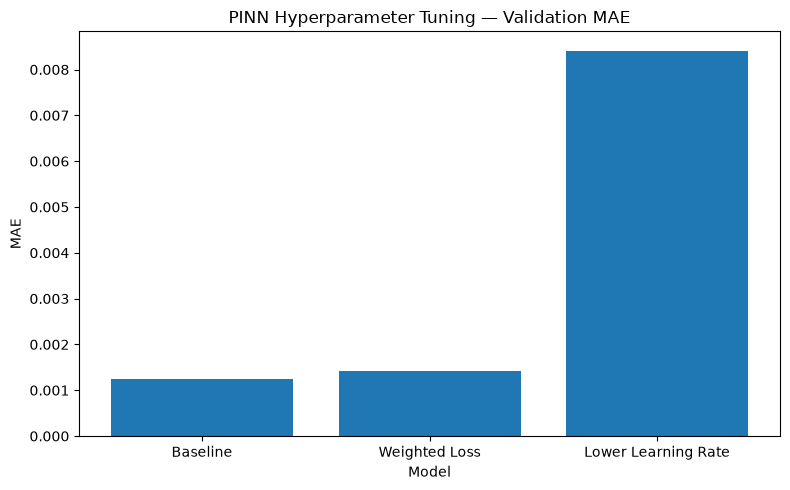

Tuning comparison plot saved.
Path:
c:\Users\LATITUDE\Documents\GitHub\PINN-Reservoir-Flow-and-Well-Pressure\results\tuning_comparison_mae.png


In [55]:
# ============================================================
# Plot Tuning Comparison — MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("PINN Hyperparameter Tuning — Validation MAE")

plt.tight_layout()

tuning_plot_path = os.path.join(
    "..",
    "results",
    "tuning_comparison_mae.png"
)

plt.savefig(
    tuning_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Tuning comparison plot saved.")
print("Path:")
print(os.path.abspath(tuning_plot_path))

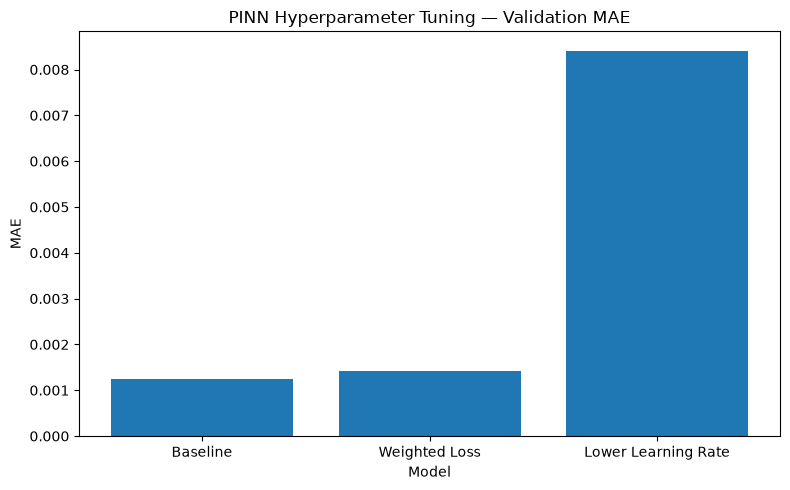

Tuning comparison plot saved.
Path:
c:\Users\LATITUDE\Documents\GitHub\PINN-Reservoir-Flow-and-Well-Pressure\results\tuning_comparison_mae.png


In [56]:
# ============================================================
# Plot Tuning Comparison — MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("PINN Hyperparameter Tuning — Validation MAE")

plt.tight_layout()

tuning_plot_path = os.path.join(
    "..",
    "results",
    "tuning_comparison_mae.png"
)

plt.savefig(
    tuning_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Tuning comparison plot saved.")
print("Path:")
print(os.path.abspath(tuning_plot_path))

In [57]:
# ============================================================
# Physical Reservoir Properties
# ============================================================

# Permeability
k_mD = 100.0

# Porosity
phi = 0.20

# Oil viscosity
mu_cP = 2.0

# Total compressibility
ct = 1.5e-9

# Unit conversions
k = k_mD * 9.869e-16       # m²
mu = mu_cP * 1e-3          # Pa·s

# Reservoir diffusivity
alpha_physical = k / (phi * mu * ct)

print("Reservoir properties:")
print(f"Permeability: {k_mD} mD = {k:.4e} m²")
print(f"Porosity: {phi}")
print(f"Viscosity: {mu_cP} cP = {mu:.4e} Pa·s")
print(f"Total compressibility: {ct:.4e} Pa⁻¹")
print(f"Reservoir diffusivity: {alpha_physical:.4e} m²/s")

Reservoir properties:
Permeability: 100.0 mD = 9.8690e-14 m²
Porosity: 0.2
Viscosity: 2.0 cP = 2.0000e-03 Pa·s
Total compressibility: 1.5000e-09 Pa⁻¹
Reservoir diffusivity: 1.6448e-01 m²/s


In [58]:
# ============================================================
# Physical Reservoir Domain
# ============================================================

# Reservoir dimensions
Lx = 1000.0       # m
Ly = 1000.0       # m

# Simulation time
T_days = 30.0
T_seconds = T_days * 24 * 60 * 60

# Reservoir diffusivity from physical properties
alpha = alpha_physical

# Characteristic diffusion time
diffusion_time = (Lx ** 2) / alpha
diffusion_time_days = diffusion_time / (24 * 60 * 60)

print("Physical reservoir domain:")
print(f"Lx: {Lx:.1f} m")
print(f"Ly: {Ly:.1f} m")
print(f"Simulation time: {T_days:.1f} days")
print(f"Simulation time: {T_seconds:.2e} s")
print(f"Diffusivity: {alpha:.4e} m²/s")
print(f"Characteristic diffusion time: {diffusion_time_days:.2f} days")

Physical reservoir domain:
Lx: 1000.0 m
Ly: 1000.0 m
Simulation time: 30.0 days
Simulation time: 2.59e+06 s
Diffusivity: 1.6448e-01 m²/s
Characteristic diffusion time: 70.37 days


In [59]:
# ============================================================
# Finite-Difference Stability Check
# ============================================================

Nx = 51
Ny = 51

dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

# Explicit 2D finite-difference stability limit
dt_max = min(dx**2, dy**2) / (4 * alpha)

print("Spatial discretization:")
print(f"Nx: {Nx}")
print(f"Ny: {Ny}")
print(f"dx: {dx:.2f} m")
print(f"dy: {dy:.2f} m")

print("\nStability limit:")
print(f"Maximum stable dt: {dt_max:.2f} seconds")
print(f"Maximum stable dt: {dt_max/86400:.4f} days")

Spatial discretization:
Nx: 51
Ny: 51
dx: 20.00 m
dy: 20.00 m

Stability limit:
Maximum stable dt: 607.96 seconds
Maximum stable dt: 0.0070 days


In [60]:
# ============================================================
# Physical Reference Grid
# ============================================================

dt = 500.0  # seconds

Nt = int(T_seconds / dt) + 1

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
time = np.arange(Nt) * dt

print("Physical reference grid:")
print(f"Spatial grid: {Nx} × {Ny}")
print(f"dx: {dx:.2f} m")
print(f"dy: {dy:.2f} m")
print(f"Time step: {dt:.1f} s")
print(f"Number of time steps: {Nt}")
print(f"Final simulated time: {time[-1]/86400:.4f} days")

Physical reference grid:
Spatial grid: 51 × 51
dx: 20.00 m
dy: 20.00 m
Time step: 500.0 s
Number of time steps: 5185
Final simulated time: 30.0000 days


In [61]:
# ============================================================
# Physical Reservoir Initial Condition
# ============================================================

def initial_pressure_physical(x, y):
    return (
        np.sin(np.pi * x / Lx)
        * np.sin(np.pi * y / Ly)
    )

# Create initial pressure field
pressure = np.zeros((Nt, Nx, Ny))

pressure[0] = initial_pressure_physical(
    x[:, None],
    y[None, :]
)

print("Initial pressure field created.")
print("Shape:", pressure.shape)
print("Minimum pressure:", pressure[0].min())
print("Maximum pressure:", pressure[0].max())
print(
    "Center pressure:",
    pressure[0, Nx // 2, Ny // 2]
)

Initial pressure field created.
Shape: (5185, 51, 51)
Minimum pressure: 0.0
Maximum pressure: 1.0
Center pressure: 1.0


In [62]:
# ============================================================
# Physical Finite-Difference Reference Solution
# ============================================================

for n in range(Nt - 1):

    # Current pressure field
    p = pressure[n]

    # Update interior grid points
    pressure[n + 1, 1:-1, 1:-1] = (
        p[1:-1, 1:-1]
        + alpha * dt * (
            (p[2:, 1:-1] - 2*p[1:-1, 1:-1] + p[:-2, 1:-1]) / dx**2
            +
            (p[1:-1, 2:] - 2*p[1:-1, 1:-1] + p[1:-1, :-2]) / dy**2
        )
    )

    # Boundary conditions: p = 0
    pressure[n + 1, 0, :] = 0.0
    pressure[n + 1, -1, :] = 0.0
    pressure[n + 1, :, 0] = 0.0
    pressure[n + 1, :, -1] = 0.0

print("Physical finite-difference solution generated.")
print("Pressure array shape:", pressure.shape)
print("Initial maximum pressure:", pressure[0].max())
print("Final maximum pressure:", pressure[-1].max())

Physical finite-difference solution generated.
Pressure array shape: (5185, 51, 51)
Initial maximum pressure: 1.0
Final maximum pressure: 0.0002204817546215661


In [63]:
# ============================================================
# Physical Finite-Difference Reference Solution
# ============================================================

for n in range(Nt - 1):

    # Current pressure field
    p = pressure[n]

    # Update interior grid points
    pressure[n + 1, 1:-1, 1:-1] = (
        p[1:-1, 1:-1]
        + alpha * dt * (
            (p[2:, 1:-1] - 2*p[1:-1, 1:-1] + p[:-2, 1:-1]) / dx**2
            +
            (p[1:-1, 2:] - 2*p[1:-1, 1:-1] + p[1:-1, :-2]) / dy**2
        )
    )

    # Boundary conditions: p = 0
    pressure[n + 1, 0, :] = 0.0
    pressure[n + 1, -1, :] = 0.0
    pressure[n + 1, :, 0] = 0.0
    pressure[n + 1, :, -1] = 0.0

print("Physical finite-difference solution generated.")
print("Pressure array shape:", pressure.shape)
print("Initial maximum pressure:", pressure[0].max())
print("Final maximum pressure:", pressure[-1].max())

Physical finite-difference solution generated.
Pressure array shape: (5185, 51, 51)
Initial maximum pressure: 1.0
Final maximum pressure: 0.0002204817546215661


Selected time:
Requested: 15.0 days
Actual: 15.0000 days

Pressure range:
Minimum: 0.000000
Maximum: 0.014849


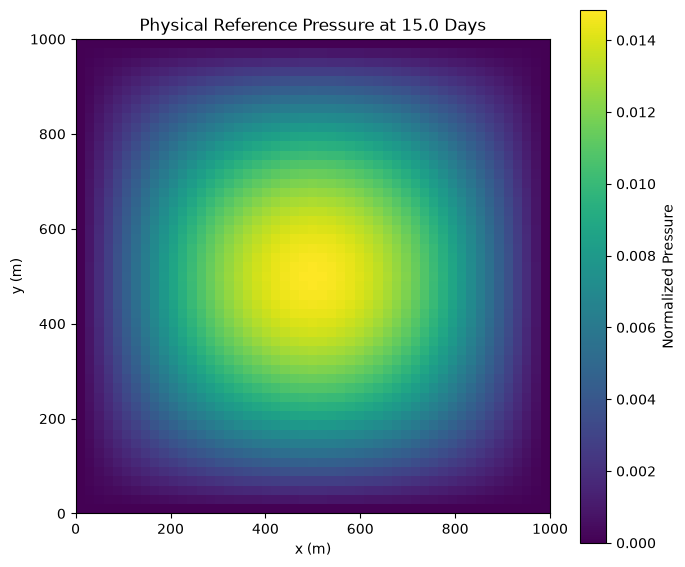

In [64]:
# ============================================================
# Physical Reference Pressure at 15 Days
# ============================================================

target_day = 15.0
target_time = target_day * 24 * 60 * 60

time_index = np.argmin(
    np.abs(time - target_time)
)

pressure_mid = pressure[time_index]

print("Selected time:")
print(f"Requested: {target_day:.1f} days")
print(
    f"Actual: {time[time_index] / 86400:.4f} days"
)

print("\nPressure range:")
print(f"Minimum: {pressure_mid.min():.6f}")
print(f"Maximum: {pressure_mid.max():.6f}")

plt.figure(figsize=(7, 6))

plt.imshow(
    pressure_mid.T,
    extent=[0, Lx, 0, Ly],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label="Normalized Pressure")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(
    f"Physical Reference Pressure at "
    f"{time[time_index] / 86400:.1f} Days"
)

plt.tight_layout()

plt.show()

In [65]:
# ============================================================
# Save Physical Reference Solution
# ============================================================

reference_physical_path = os.path.join(
    "..",
    "data",
    "reference_physical_reservoir.npz"
)

np.savez_compressed(
    reference_physical_path,
    x=x,
    y=y,
    time=time,
    pressure=pressure,
    alpha=alpha,
    permeability=k,
    porosity=phi,
    viscosity=mu,
    compressibility=ct
)

print("Physical reference solution saved successfully.")
print("Path:")
print(os.path.abspath(reference_physical_path))
print("Pressure array shape:", pressure.shape)

Physical reference solution saved successfully.
Path:
c:\Users\LATITUDE\Documents\GitHub\PINN-Reservoir-Flow-and-Well-Pressure\data\reference_physical_reservoir.npz
Pressure array shape: (5185, 51, 51)


In [66]:
# ============================================================
# Load and Verify Physical Reference Solution
# ============================================================

reference_data = np.load(
    "../data/reference_physical_reservoir.npz"
)

print("Stored variables:")
print(reference_data.files)

print("\nPressure shape:")
print(reference_data["pressure"].shape)

print("\nPhysical parameters:")
print(f"Alpha: {reference_data['alpha']:.6e} m²/s")
print(f"Permeability: {reference_data['permeability']:.6e} m²")
print(f"Porosity: {reference_data['porosity']}")
print(f"Viscosity: {reference_data['viscosity']:.6e} Pa·s")
print(
    f"Compressibility: "
    f"{reference_data['compressibility']:.6e} Pa⁻¹"
)

Stored variables:
['x', 'y', 'time', 'pressure', 'alpha', 'permeability', 'porosity', 'viscosity', 'compressibility']

Pressure shape:
(5185, 51, 51)

Physical parameters:
Alpha: 1.644833e-01 m²/s
Permeability: 9.869000e-14 m²
Porosity: 0.2
Viscosity: 2.000000e-03 Pa·s
Compressibility: 1.500000e-09 Pa⁻¹


In [67]:
# ============================================================
# Physical PINN — Normalized Coordinates
# ============================================================

# Load physical reference arrays
x_physical = reference_data["x"]
y_physical = reference_data["y"]
time_physical = reference_data["time"]

# Physical domain limits
Lx_physical = 1000.0
Ly_physical = 1000.0
T_physical = 30.0 * 24 * 60 * 60

# Normalize coordinates to approximately [0, 1]
x_normalized = x_physical / Lx_physical
y_normalized = y_physical / Ly_physical
t_normalized = time_physical / T_physical

print("Normalized coordinate ranges:")
print(
    f"x*: {x_normalized.min():.1f} → "
    f"{x_normalized.max():.1f}"
)
print(
    f"y*: {y_normalized.min():.1f} → "
    f"{y_normalized.max():.1f}"
)
print(
    f"t*: {t_normalized.min():.1f} → "
    f"{t_normalized.max():.1f}"
)

Normalized coordinate ranges:
x*: 0.0 → 1.0
y*: 0.0 → 1.0
t*: 0.0 → 1.0


In [68]:
# ============================================================
# Dimensionless Diffusion Coefficient
# ============================================================

alpha_dimensionless = (
    alpha
    * T_physical
    / (Lx_physical ** 2)
)

print("Dimensionless diffusion coefficient:")
print(f"alpha* = {alpha_dimensionless:.6f}")

Dimensionless diffusion coefficient:
alpha* = 0.426341


In [69]:
# ============================================================
# Physical Reservoir PINN — PDE Residual
# ============================================================

def physical_pde_residual(model, X):

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(X)

        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(X)

            pressure_pred = model(X)

        # First derivatives with respect to normalized coordinates
        pressure_grad = tape1.gradient(
            pressure_pred,
            X
        )

        dp_dx = pressure_grad[:, 0:1]
        dp_dy = pressure_grad[:, 1:2]
        dp_dt = pressure_grad[:, 2:3]

    # Second derivatives
    d2p_dx2 = tape2.gradient(
        dp_dx,
        X
    )[:, 0:1]

    d2p_dy2 = tape2.gradient(
        dp_dy,
        X
    )[:, 1:2]

    # Dimensionless physical PDE residual
    residual = (
        dp_dt
        - alpha_dimensionless * (
            d2p_dx2 + d2p_dy2
        )
    )

    del tape1
    del tape2

    return residual

print("Physical PDE residual function created successfully.")

Physical PDE residual function created successfully.


In [70]:
# ============================================================
# Test Physical PDE Residual
# ============================================================

# Convert collocation points to tensors if needed
X_collocation_physical_tf = tf.convert_to_tensor(
    X_collocation,
    dtype=tf.float32
)

# Calculate PDE residual
physical_residual = physical_pde_residual(
    model,
    X_collocation_physical_tf
)

print("Physical PDE residual test")
print("--------------------------")
print("Residual shape:", physical_residual.shape)
print("First 5 residuals:")
print(physical_residual[:5].numpy())

print("\nMean squared residual:")
print(
    tf.reduce_mean(
        tf.square(physical_residual)
    ).numpy()
)

Physical PDE residual test
--------------------------
Residual shape: (10000, 1)
First 5 residuals:
[[1.3083069]
 [0.5860486]
 [1.2614564]
 [1.5768473]
 [1.1893065]]

Mean squared residual:
2.6092632


In [71]:
# ============================================================
# Physical Reservoir PINN
# ============================================================

physical_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

physical_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Physical reservoir PINN created.")
print("Trainable parameters:", physical_model.count_params())
print("Learning rate: 0.001")
print(f"Dimensionless diffusivity: {alpha_dimensionless:.6f}")

Physical reservoir PINN created.
Trainable parameters: 7901
Learning rate: 0.001
Dimensionless diffusivity: 0.426341


In [72]:
# ============================================================
# Physical Reservoir PINN Loss
# ============================================================

def physical_pinn_loss(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):
    # Physics loss
    residual = physical_pde_residual(
        model,
        X_collocation
    )

    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )

    # Initial-condition loss
    pressure_initial_pred = model(
        X_initial
    )

    initial_loss = tf.reduce_mean(
        tf.square(
            pressure_initial_pred - P_initial
        )
    )

    # Boundary-condition loss
    pressure_boundary_pred = model(
        X_boundary
    )

    boundary_loss = tf.reduce_mean(
        tf.square(
            pressure_boundary_pred - P_boundary
        )
    )

    # Equal weighting for baseline physical model
    total_loss = (
        physics_loss
        + initial_loss
        + boundary_loss
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

print("Physical PINN loss created successfully.")

Physical PINN loss created successfully.


In [73]:
# ============================================================
# Physical Reservoir PINN Training Step
# ============================================================

def physical_train_step(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):
    with tf.GradientTape() as tape:

        (
            total_loss,
            physics_loss,
            initial_loss,
            boundary_loss
        ) = physical_pinn_loss(
            model,
            X_collocation,
            X_initial,
            P_initial,
            X_boundary,
            P_boundary
        )

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    physical_optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

print("Physical PINN training step created successfully.")

Physical PINN training step created successfully.


In [74]:
# ============================================================
# One-Step Test — Physical Reservoir PINN
# ============================================================

before_total, before_physics, before_initial, before_boundary = (
    physical_pinn_loss(
        physical_model,
        X_collocation_physical_tf,
        X_initial_tf,
        P_initial_tf,
        X_boundary_tf,
        P_boundary_tf
    )
)

physical_train_step(
    physical_model,
    X_collocation_physical_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

after_total, after_physics, after_initial, after_boundary = (
    physical_pinn_loss(
        physical_model,
        X_collocation_physical_tf,
        X_initial_tf,
        P_initial_tf,
        X_boundary_tf,
        P_boundary_tf
    )
)

print("Before training step:")
print("Total loss:", before_total.numpy())

print("\nAfter training step:")
print("Total loss:", after_total.numpy())

print("\nLoss components after step:")
print("Physics:", after_physics.numpy())
print("Initial:", after_initial.numpy())
print("Boundary:", after_boundary.numpy())


Before training step:
Total loss: 0.23362878

After training step:
Total loss: 0.20121415

Loss components after step:
Physics: 0.0016815752
Initial: 0.11034982
Boundary: 0.08918276


In [75]:
# ============================================================
# Reset Physical Reservoir PINN for Clean Training
# ============================================================

physical_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

physical_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Physical PINN reset successfully.")
print("Trainable parameters:", physical_model.count_params())
print("Learning rate: 0.001")
print(f"Dimensionless diffusivity: {alpha_dimensionless:.6f}")

Physical PINN reset successfully.
Trainable parameters: 7901
Learning rate: 0.001
Dimensionless diffusivity: 0.426341


In [76]:
# ============================================================
# Train Physical Reservoir PINN
# ============================================================

physical_loss_history = []
physical_physics_history = []
physical_initial_history = []
physical_boundary_history = []

epochs = 5000

for epoch in range(epochs):

    (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    ) = physical_train_step(
        physical_model,
        X_collocation_physical_tf,
        X_initial_tf,
        P_initial_tf,
        X_boundary_tf,
        P_boundary_tf
    )

    physical_loss_history.append(total_loss.numpy())
    physical_physics_history.append(physics_loss.numpy())
    physical_initial_history.append(initial_loss.numpy())
    physical_boundary_history.append(boundary_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {total_loss.numpy():.6f} | "
            f"Physics: {physics_loss.numpy():.6f} | "
            f"Initial: {initial_loss.numpy():.6f} | "
            f"Boundary: {boundary_loss.numpy():.6f}"
        )

Epoch     0 | Total: 0.374112 | Physics: 0.181680 | Initial: 0.142750 | Boundary: 0.049682
Epoch   500 | Total: 0.015736 | Physics: 0.003492 | Initial: 0.008629 | Boundary: 0.003615
Epoch  1000 | Total: 0.003605 | Physics: 0.001285 | Initial: 0.001479 | Boundary: 0.000841
Epoch  1500 | Total: 0.001656 | Physics: 0.000606 | Initial: 0.000585 | Boundary: 0.000465
Epoch  2000 | Total: 0.001271 | Physics: 0.000498 | Initial: 0.000416 | Boundary: 0.000358
Epoch  2500 | Total: 0.000645 | Physics: 0.000248 | Initial: 0.000193 | Boundary: 0.000205
Epoch  3000 | Total: 0.000455 | Physics: 0.000178 | Initial: 0.000127 | Boundary: 0.000149
Epoch  3500 | Total: 0.000617 | Physics: 0.000198 | Initial: 0.000229 | Boundary: 0.000190
Epoch  4000 | Total: 0.000689 | Physics: 0.000157 | Initial: 0.000291 | Boundary: 0.000241
Epoch  4500 | Total: 0.005238 | Physics: 0.004597 | Initial: 0.000291 | Boundary: 0.000351


In [77]:
# ============================================================
# Physical PINN Validation Set
# ============================================================

physical_reference_df = pd.DataFrame({
    "x": np.repeat(
        x_physical,
        len(y_physical) * len(time_physical)
    ),
    "y": np.tile(
        np.repeat(
            y_physical,
            len(time_physical)
        ),
        len(x_physical)
    ),
    "time": np.tile(
        time_physical,
        len(x_physical) * len(y_physical)
    )
})

physical_reference_df["pressure"] = (
    pressure.flatten()
)

print("Physical reference dataset shape:")
print(physical_reference_df.shape)

Physical reference dataset shape:
(13486185, 4)


In [78]:
# ============================================================
# Physical PINN Validation Set — Memory Efficient
# ============================================================

N_validation_physical = 10000

rng = np.random.default_rng(42)

time_indices = rng.integers(
    0,
    len(time_physical),
    N_validation_physical
)

x_indices = rng.integers(
    0,
    len(x_physical),
    N_validation_physical
)

y_indices = rng.integers(
    0,
    len(y_physical),
    N_validation_physical
)

X_validation_physical = np.column_stack((
    x_physical[x_indices] / Lx_physical,
    y_physical[y_indices] / Ly_physical,
    time_physical[time_indices] / T_physical
))

P_reference_physical = pressure[
    time_indices,
    x_indices,
    y_indices
].reshape(-1, 1)

X_validation_physical_tf = tf.convert_to_tensor(
    X_validation_physical,
    dtype=tf.float32
)

P_reference_physical_tf = tf.convert_to_tensor(
    P_reference_physical,
    dtype=tf.float32
)

print("Physical validation inputs shape:")
print(X_validation_physical.shape)

print("Physical reference pressures shape:")
print(P_reference_physical.shape)

print("\nFirst validation point:")
print(X_validation_physical[0])

print("Reference pressure:")
print(P_reference_physical[0])

Physical validation inputs shape:
(10000, 3)
Physical reference pressures shape:
(10000, 1)

First validation point:
[0.34       0.02       0.08912037]
Reference pressure:
[0.02598186]


In [79]:
# ============================================================
# Validate Physical Reservoir PINN
# ============================================================

P_physical_pinn = physical_model(
    X_validation_physical_tf,
    training=False
)

P_physical_pinn_np = P_physical_pinn.numpy()

# Errors
absolute_error_physical = np.abs(
    P_physical_pinn_np - P_reference_physical
)

squared_error_physical = (
    P_physical_pinn_np - P_reference_physical
) ** 2

# Metrics
mae_physical = np.mean(
    absolute_error_physical
)

rmse_physical = np.sqrt(
    np.mean(squared_error_physical)
)

max_error_physical = np.max(
    absolute_error_physical
)

print("Physical Reservoir PINN Validation Results")
print("-------------------------------------------")
print(f"MAE:           {mae_physical:.8f}")
print(f"RMSE:          {rmse_physical:.8f}")
print(f"Maximum error: {max_error_physical:.8f}")

Physical Reservoir PINN Validation Results
-------------------------------------------
MAE:           0.00339868
RMSE:          0.00469791
Maximum error: 0.03752510


In [80]:
# ============================================================
# Physical PINN vs Reference at 15 Days
# ============================================================

target_day = 15.0
target_time = target_day * 24 * 60 * 60

time_index = np.argmin(
    np.abs(time_physical - target_time)
)

actual_day = (
    time_physical[time_index] / 86400
)

# Create the 51 × 51 spatial grid
X_grid, Y_grid = np.meshgrid(
    x_physical,
    y_physical,
    indexing="ij"
)

# Flatten grid and normalize coordinates
X_spatial = np.column_stack((
    X_grid.ravel() / Lx_physical,
    Y_grid.ravel() / Ly_physical,
    np.full(X_grid.size, actual_day / 30.0)
))

X_spatial_tf = tf.convert_to_tensor(
    X_spatial,
    dtype=tf.float32
)

# PINN prediction
P_pinn_15 = physical_model(
    X_spatial_tf,
    training=False
).numpy().reshape(Nx, Ny)

# Reference solution
P_reference_15 = pressure[
    time_index
]

# Absolute error
P_error_15 = np.abs(
    P_pinn_15 - P_reference_15
)

print("15-day physical PINN comparison")
print("--------------------------------")
print(f"Actual time: {actual_day:.4f} days")

print("\nReference:")
print(f"Min: {P_reference_15.min():.6f}")
print(f"Max: {P_reference_15.max():.6f}")

print("\nPINN:")
print(f"Min: {P_pinn_15.min():.6f}")
print(f"Max: {P_pinn_15.max():.6f}")

print("\nAbsolute error:")
print(f"Mean: {P_error_15.mean():.6f}")
print(f"Maximum: {P_error_15.max():.6f}")

15-day physical PINN comparison
--------------------------------
Actual time: 15.0000 days

Reference:
Min: 0.000000
Max: 0.014849

PINN:
Min: -0.007912
Max: 0.012532

Absolute error:
Mean: 0.003194
Maximum: 0.007912


In [81]:
# ============================================================
# Analytical Solution — 15 Days
# ============================================================

# Create 2D physical grid
X_phys, Y_phys = np.meshgrid(
    x_physical,
    y_physical,
    indexing="ij"
)

t_15 = 15.0 * 24 * 60 * 60

# Analytical solution
P_analytical_15 = (
    np.sin(np.pi * X_phys / Lx_physical)
    * np.sin(np.pi * Y_phys / Ly_physical)
    * np.exp(
        -alpha
        * (
            (np.pi / Lx_physical) ** 2
            + (np.pi / Ly_physical) ** 2
        )
        * t_15
    )
)

# Compare with finite-difference reference
FD_error_15 = np.abs(
    P_analytical_15 - P_reference_15
)

print("Analytical solution at 15 days")
print("--------------------------------")
print(f"Minimum: {P_analytical_15.min():.6f}")
print(f"Maximum: {P_analytical_15.max():.6f}")

print("\nFinite-difference comparison:")
print(f"MAE: {FD_error_15.mean():.8f}")
print(f"RMSE: {np.sqrt(np.mean(FD_error_15**2)):.8f}")
print(f"Maximum error: {FD_error_15.max():.8f}")

Analytical solution at 15 days
--------------------------------
Minimum: 0.000000
Maximum: 0.014879

Finite-difference comparison:
MAE: 0.00001176
RMSE: 0.00001481
Maximum error: 0.00003021


In [82]:
# ============================================================
# Create 15-Day Prediction Grid for the Physical PINN
# ============================================================

X_15, Y_15 = np.meshgrid(
    x_physical,
    y_physical,
    indexing="ij"
)

X_grid_physical_15 = np.column_stack((
    X_15.ravel() / Lx_physical,
    Y_15.ravel() / Ly_physical,
    np.full(X_15.size, t_15 / T_physical)
))

print("15-day PINN prediction grid")
print("---------------------------")
print("Shape:", X_grid_physical_15.shape)
print("First point:", X_grid_physical_15[0])
print("Last point:", X_grid_physical_15[-1])

15-day PINN prediction grid
---------------------------
Shape: (2601, 3)
First point: [0.  0.  0.5]
Last point: [1.  1.  0.5]


In [83]:
# ============================================================
# 15-Day Analytical vs Finite-Difference vs PINN
# ============================================================

P_pinn_15 = physical_model.predict(
    X_grid_physical_15,
    verbose=0
).reshape(len(x_physical), len(y_physical))

print("15-day comparison")
print("-----------------")
print(f"Analytical maximum:        {P_analytical_15.max():.6f}")
print(f"Finite-difference maximum: {P_reference_15.max():.6f}")
print(f"PINN maximum:              {P_pinn_15.max():.6f}")

# PINN errors against analytical solution
PINN_error_15 = np.abs(
    P_pinn_15 - P_analytical_15
)

print("\nPINN vs analytical solution:")
print(f"MAE:             {PINN_error_15.mean():.8f}")
print(f"RMSE:            {np.sqrt(np.mean(PINN_error_15**2)):.8f}")
print(f"Maximum error:   {PINN_error_15.max():.8f}")

15-day comparison
-----------------
Analytical maximum:        0.014879
Finite-difference maximum: 0.014849
PINN maximum:              0.012532

PINN vs analytical solution:
MAE:             0.00320565
RMSE:            0.00351586
Maximum error:   0.00791200


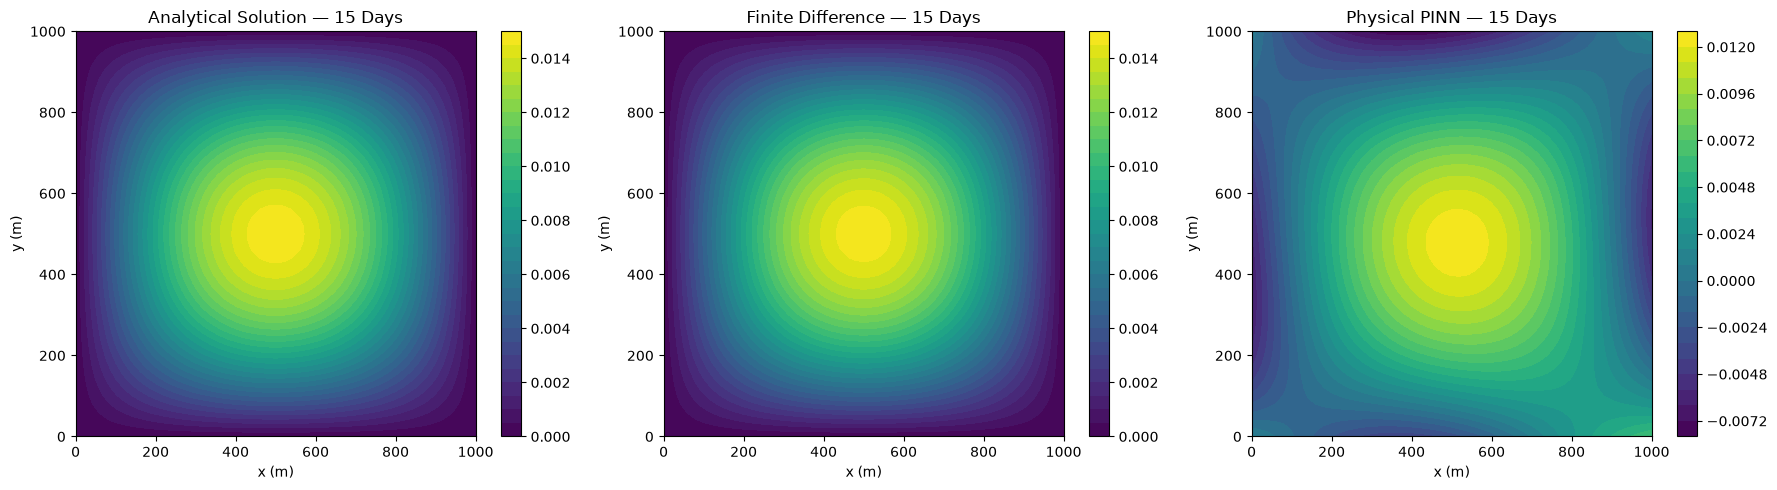

In [84]:
# ============================================================
# 15-Day Spatial Comparison
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Analytical
im1 = axes[0].contourf(
    X_15,
    Y_15,
    P_analytical_15,
    levels=30
)
axes[0].set_title("Analytical Solution — 15 Days")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
fig.colorbar(im1, ax=axes[0])

# Finite difference
im2 = axes[1].contourf(
    X_15,
    Y_15,
    P_reference_15,
    levels=30
)
axes[1].set_title("Finite Difference — 15 Days")
axes[1].set_xlabel("x (m)")
axes[1].set_ylabel("y (m)")
fig.colorbar(im2, ax=axes[1])

# PINN
im3 = axes[2].contourf(
    X_15,
    Y_15,
    P_pinn_15,
    levels=30
)
axes[2].set_title("Physical PINN — 15 Days")
axes[2].set_xlabel("x (m)")
axes[2].set_ylabel("y (m)")
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

In [85]:
# ============================================================
# Quantify PINN Boundary Condition Error at 15 Days
# ============================================================

# Four boundaries at t = 15 days
X_left = np.column_stack((
    np.zeros(len(y_physical)),
    y_physical / Ly_physical,
    np.full(len(y_physical), t_15 / T_physical)
))

X_right = np.column_stack((
    np.ones(len(y_physical)),
    y_physical / Ly_physical,
    np.full(len(y_physical), t_15 / T_physical)
))

X_bottom = np.column_stack((
    x_physical / Lx_physical,
    np.zeros(len(x_physical)),
    np.full(len(x_physical), t_15 / T_physical)
))

X_top = np.column_stack((
    x_physical / Lx_physical,
    np.ones(len(x_physical)),
    np.full(len(x_physical), t_15 / T_physical)
))

# Predictions
P_left = physical_model.predict(X_left, verbose=0).flatten()
P_right = physical_model.predict(X_right, verbose=0).flatten()
P_bottom = physical_model.predict(X_bottom, verbose=0).flatten()
P_top = physical_model.predict(X_top, verbose=0).flatten()

# Combine all boundaries
P_boundary_15 = np.concatenate([
    P_left,
    P_right,
    P_bottom,
    P_top
])

print("PINN boundary condition error at 15 days")
print("-----------------------------------------")
print(f"Mean absolute boundary pressure: {np.mean(np.abs(P_boundary_15)):.8f}")
print(f"Maximum absolute boundary pressure: {np.max(np.abs(P_boundary_15)):.8f}")
print(f"Minimum boundary pressure: {P_boundary_15.min():.8f}")
print(f"Maximum boundary pressure: {P_boundary_15.max():.8f}")

PINN boundary condition error at 15 days
-----------------------------------------
Mean absolute boundary pressure: 0.00359776
Maximum absolute boundary pressure: 0.00791200
Minimum boundary pressure: -0.00791200
Maximum boundary pressure: 0.00634239


In [86]:
# ============================================================
# Physical PINN — Stronger Boundary Enforcement
# ============================================================

boundary_weight = 5.0

def physical_pinn_loss_weighted(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):
    
    # Physics loss
    residual = physical_pde_residual(
        model,
        X_collocation
    )
    
    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )
    
    # Initial-condition loss
    pressure_initial_pred = model(X_initial)
    
    initial_loss = tf.reduce_mean(
        tf.square(
            pressure_initial_pred - P_initial
        )
    )
    
    # Boundary-condition loss
    pressure_boundary_pred = model(X_boundary)
    
    boundary_loss = tf.reduce_mean(
        tf.square(
            pressure_boundary_pred - P_boundary
        )
    )
    
    # Weighted total loss
    total_loss = (
        physics_loss
        + initial_loss
        + boundary_weight * boundary_loss
    )
    
    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )


print("Boundary weight:", boundary_weight)
print("Weighted physical PINN loss function created successfully.")

Boundary weight: 5.0
Weighted physical PINN loss function created successfully.


In [87]:
# ============================================================
# Fresh Physical PINN — Boundary-Weighted Experiment
# ============================================================

weighted_physical_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

weighted_physical_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Fresh weighted physical PINN created.")
print(
    "Trainable parameters:",
    weighted_physical_model.count_params()
)

Fresh weighted physical PINN created.
Trainable parameters: 7901


In [88]:
# ============================================================
# Training Step — Boundary-Weighted Physical PINN
# ============================================================

def weighted_physical_train_step(
    model,
    optimizer,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):
    
    with tf.GradientTape() as tape:
        
        total_loss, physics_loss, initial_loss, boundary_loss = (
            physical_pinn_loss_weighted(
                model,
                X_collocation,
                X_initial,
                P_initial,
                X_boundary,
                P_boundary
            )
        )
    
    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )
    
    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )
    
    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )


print("Weighted physical PINN training step created successfully.")

Weighted physical PINN training step created successfully.


In [89]:
# ============================================================
# One-Step Test — Boundary-Weighted Physical PINN
# ============================================================

loss_before = physical_pinn_loss_weighted(
    weighted_physical_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("Before training step")
print("--------------------")
print(f"Total loss:    {loss_before[0].numpy():.8f}")
print(f"Physics loss:  {loss_before[1].numpy():.8f}")
print(f"Initial loss:  {loss_before[2].numpy():.8f}")
print(f"Boundary loss: {loss_before[3].numpy():.8f}")


# Perform one training step
loss_after = weighted_physical_train_step(
    weighted_physical_model,
    weighted_physical_optimizer,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("\nAfter training step")
print("-------------------")
print(f"Total loss:    {loss_after[0].numpy():.8f}")
print(f"Physics loss:  {loss_after[1].numpy():.8f}")
print(f"Initial loss:  {loss_after[2].numpy():.8f}")
print(f"Boundary loss: {loss_after[3].numpy():.8f}")

Before training step
--------------------
Total loss:    0.26411363
Physics loss:  0.00051878
Initial loss:  0.26110306
Boundary loss: 0.00049836

After training step
-------------------
Total loss:    0.26411363
Physics loss:  0.00051878
Initial loss:  0.26110306
Boundary loss: 0.00049836


In [90]:
# ============================================================
# Gradient Diagnostic — Boundary-Weighted Physical PINN
# ============================================================

with tf.GradientTape() as tape:

    total_loss, physics_loss, initial_loss, boundary_loss = (
        physical_pinn_loss_weighted(
            weighted_physical_model,
            X_collocation_tf,
            X_initial_tf,
            P_initial_tf,
            X_boundary_tf,
            P_boundary_tf
        )
    )

gradients = tape.gradient(
    total_loss,
    weighted_physical_model.trainable_variables
)

print("Gradient diagnostic")
print("-------------------")

for i, (variable, gradient) in enumerate(
    zip(weighted_physical_model.trainable_variables, gradients)
):
    
    if gradient is None:
        print(i, variable.name, "→ None")
    else:
        print(
            i,
            variable.name,
            "→ mean abs gradient:",
            tf.reduce_mean(tf.abs(gradient)).numpy()
        )

Gradient diagnostic
-------------------
0 kernel → mean abs gradient: 0.13355504
1 bias → mean abs gradient: 0.18449505
2 kernel → mean abs gradient: 0.041070044
3 bias → mean abs gradient: 0.18829006
4 kernel → mean abs gradient: 0.036207184
5 bias → mean abs gradient: 0.19168097
6 kernel → mean abs gradient: 0.038597774
7 bias → mean abs gradient: 0.21781868
8 kernel → mean abs gradient: 0.24100175
9 bias → mean abs gradient: 1.2910401


In [91]:
# ============================================================
# Check Whether Model Weights Actually Change
# ============================================================

# Save a copy of the first layer weights
weights_before = weighted_physical_model.trainable_variables[0].numpy().copy()

# Perform one training step
weighted_physical_train_step(
    weighted_physical_model,
    weighted_physical_optimizer,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

# Get the weights after the update
weights_after = weighted_physical_model.trainable_variables[0].numpy()

# Measure the change
weight_change = np.max(
    np.abs(weights_after - weights_before)
)

print("Weight update diagnostic")
print("------------------------")
print(f"Maximum weight change: {weight_change:.12e}")

Weight update diagnostic
------------------------
Maximum weight change: 9.974539279938e-04


In [92]:
# ============================================================
# Reset — Fresh Boundary-Weighted Physical PINN
# ============================================================

weighted_physical_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

weighted_physical_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Fresh model reset.")
print(
    "Trainable parameters:",
    weighted_physical_model.count_params()
)

Fresh model reset.
Trainable parameters: 7901


In [93]:
# ============================================================
# Train Boundary-Weighted Physical PINN
# ============================================================

epochs = 5000

weighted_total_history = []
weighted_physics_history = []
weighted_initial_history = []
weighted_boundary_history = []

for epoch in range(epochs):

    total_loss, physics_loss, initial_loss, boundary_loss = (
        weighted_physical_train_step(
            weighted_physical_model,
            weighted_physical_optimizer,
            X_collocation_tf,
            X_initial_tf,
            P_initial_tf,
            X_boundary_tf,
            P_boundary_tf
        )
    )

    weighted_total_history.append(total_loss.numpy())
    weighted_physics_history.append(physics_loss.numpy())
    weighted_initial_history.append(initial_loss.numpy())
    weighted_boundary_history.append(boundary_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total {total_loss.numpy():.6f} | "
            f"Physics {physics_loss.numpy():.6f} | "
            f"Initial {initial_loss.numpy():.6f} | "
            f"Boundary {boundary_loss.numpy():.6f}"
        )

print("\nTraining complete.")

Epoch    0 | Total 0.555628 | Physics 0.007398 | Initial 0.336873 | Boundary 0.042271
Epoch  500 | Total 0.028163 | Physics 0.006006 | Initial 0.011753 | Boundary 0.002081
Epoch 1000 | Total 0.006950 | Physics 0.002729 | Initial 0.001393 | Boundary 0.000566
Epoch 1500 | Total 0.002422 | Physics 0.001159 | Initial 0.000311 | Boundary 0.000190
Epoch 2000 | Total 0.001567 | Physics 0.000641 | Initial 0.000127 | Boundary 0.000160
Epoch 2500 | Total 0.000727 | Physics 0.000353 | Initial 0.000079 | Boundary 0.000059
Epoch 3000 | Total 0.000484 | Physics 0.000250 | Initial 0.000047 | Boundary 0.000037
Epoch 3500 | Total 0.000466 | Physics 0.000227 | Initial 0.000043 | Boundary 0.000039
Epoch 4000 | Total 0.000549 | Physics 0.000179 | Initial 0.000042 | Boundary 0.000065
Epoch 4500 | Total 0.000583 | Physics 0.000262 | Initial 0.000019 | Boundary 0.000061

Training complete.


In [94]:
# ============================================================
# Validate Boundary-Weighted Physical PINN
# ============================================================

P_weighted_validation = weighted_physical_model.predict(
    X_validation_physical,
    verbose=0
)

weighted_error = np.abs(
    P_weighted_validation - P_reference_physical
)

weighted_mae = weighted_error.mean()
weighted_rmse = np.sqrt(
    np.mean(
        (P_weighted_validation - P_reference_physical) ** 2
    )
)
weighted_max_error = weighted_error.max()

print("Boundary-weighted physical PINN validation")
print("--------------------------------------------")
print(f"MAE:           {weighted_mae:.8f}")
print(f"RMSE:          {weighted_rmse:.8f}")
print(f"Maximum error: {weighted_max_error:.8f}")

Boundary-weighted physical PINN validation
--------------------------------------------
MAE:           0.00267420
RMSE:          0.00333796
Maximum error: 0.01414013


In [95]:
# ============================================================
# Physical PINN Accuracy at Multiple Times
# ============================================================

evaluation_days = [1, 5, 15, 30]

print("Physical PINN — Time-Dependent Validation")
print("==========================================")

for days in evaluation_days:

    # Convert days to seconds
    t_eval = days * 24 * 60 * 60

    # Normalized time
    t_star = t_eval / T_physical

    # Create spatial prediction grid
    X_eval, Y_eval = np.meshgrid(
        x_physical,
        y_physical,
        indexing="ij"
    )

    X_grid_eval = np.column_stack((
        X_eval.ravel() / Lx_physical,
        Y_eval.ravel() / Ly_physical,
        np.full(X_eval.size, t_star)
    ))

    # PINN prediction
    P_pinn_eval = physical_model.predict(
        X_grid_eval,
        verbose=0
    ).reshape(
        len(x_physical),
        len(y_physical)
    )

    # Analytical solution
    P_analytical_eval = (
        np.sin(np.pi * X_eval / Lx_physical)
        * np.sin(np.pi * Y_eval / Ly_physical)
        * np.exp(
            -alpha
            * (
                (np.pi / Lx_physical) ** 2
                + (np.pi / Ly_physical) ** 2
            )
            * t_eval
        )
    )

    # Error
    error = np.abs(
        P_pinn_eval - P_analytical_eval
    )

    mae = error.mean()
    rmse = np.sqrt(np.mean(error**2))
    max_error = error.max()

    print(f"\n{days} days")
    print(f"Analytical max: {P_analytical_eval.max():.8f}")
    print(f"PINN max:       {P_pinn_eval.max():.8f}")
    print(f"MAE:            {mae:.8f}")
    print(f"RMSE:           {rmse:.8f}")
    print(f"Max error:      {max_error:.8f}")

Physical PINN — Time-Dependent Validation

1 days
Analytical max: 0.75539008
PINN max:       0.75657701
MAE:            0.00573291
RMSE:           0.00841954
Max error:      0.04001871

5 days
Analytical max: 0.24595541
PINN max:       0.25362465
MAE:            0.00686702
RMSE:           0.00743839
Max error:      0.01518002

15 days
Analytical max: 0.01487884
PINN max:       0.01253212
MAE:            0.00320565
RMSE:           0.00351586
Max error:      0.00791200

30 days
Analytical max: 0.00022138
PINN max:       0.01191715
MAE:            0.00222524
RMSE:           0.00314666
Max error:      0.01191715


In [96]:
# ============================================================
# Inspect Current Collocation-Time Distribution
# ============================================================

print("Current collocation time distribution")
print("-------------------------------------")

print(f"Minimum t*: {X_collocation[:, 2].min():.6f}")
print(f"Maximum t*: {X_collocation[:, 2].max():.6f}")
print(f"Mean t*:    {X_collocation[:, 2].mean():.6f}")
print(f"Median t*:  {np.median(X_collocation[:, 2]):.6f}")

# Convert normalized time to days
collocation_days = X_collocation[:, 2] * 30.0

print("\nApproximate points by time interval:")

intervals = [
    (0, 5),
    (5, 10),
    (10, 15),
    (15, 20),
    (20, 25),
    (25, 30)
]

for start, end in intervals:
    count = np.sum(
        (collocation_days >= start) &
        (collocation_days < end)
    )
    
    print(f"{start:2d}–{end:2d} days: {count} points")

Current collocation time distribution
-------------------------------------
Minimum t*: 0.000048
Maximum t*: 0.999901
Mean t*:    0.500050
Median t*:  0.502068

Approximate points by time interval:
 0– 5 days: 1635 points
 5–10 days: 1685 points
10–15 days: 1658 points
15–20 days: 1734 points
20–25 days: 1670 points
25–30 days: 1618 points


In [97]:
# ============================================================
# Test Late-Time-Biased Collocation Distribution
# ============================================================

N_test = 10000

rng = np.random.default_rng(42)

u = rng.uniform(0, 1, N_test)

t_test = 1.0 - (1.0 - u)**2

t_test_days = t_test * 30.0

print("Late-time-biased distribution")
print("-----------------------------")
print(f"Minimum t*: {t_test.min():.6f}")
print(f"Maximum t*: {t_test.max():.6f}")
print(f"Mean t*:    {t_test.mean():.6f}")
print(f"Median t*:  {np.median(t_test):.6f}")

print("\nPoints by time interval:")

for start, end in intervals:
    count = np.sum(
        (t_test_days >= start) &
        (t_test_days < end)
    )

    print(f"{start:2d}–{end:2d} days: {count} points")

Late-time-biased distribution
-----------------------------
Minimum t*: 0.000629
Maximum t*: 1.000000
Mean t*:    0.664050
Median t*:  0.748299

Points by time interval:
 0– 5 days: 859 points
 5–10 days: 1007 points
10–15 days: 1109 points
15–20 days: 1280 points
20–25 days: 1694 points
25–30 days: 4051 points


In [98]:
# ============================================================
# Test Moderate Late-Time-Biased Distribution
# ============================================================

N_test = 10000

rng = np.random.default_rng(42)

u = rng.uniform(0, 1, N_test)

t_test_moderate = 1.0 - (1.0 - u)**1.5

t_test_moderate_days = t_test_moderate * 30.0

print("Moderate late-time-biased distribution")
print("--------------------------------------")
print(f"Minimum t*: {t_test_moderate.min():.6f}")
print(f"Maximum t*: {t_test_moderate.max():.6f}")
print(f"Mean t*:    {t_test_moderate.mean():.6f}")
print(f"Median t*:  {np.median(t_test_moderate):.6f}")

print("\nPoints by time interval:")

for start, end in intervals:
    count = np.sum(
        (t_test_moderate_days >= start) &
        (t_test_moderate_days < end)
    )

    print(f"{start:2d}–{end:2d} days: {count} points")

Moderate late-time-biased distribution
--------------------------------------
Minimum t*: 0.000472
Maximum t*: 1.000000
Mean t*:    0.597168
Median t*:  0.644644

Points by time interval:
 0– 5 days: 1134 points
 5–10 days: 1263 points
10–15 days: 1335 points
15–20 days: 1489 points
20–25 days: 1807 points
25–30 days: 2972 points


In [99]:
# ============================================================
# Generate Moderate Late-Time-Biased Collocation Points
# ============================================================

N_collocation_biased = 10000

rng = np.random.default_rng(42)

# Spatial coordinates remain uniformly distributed
x_collocation_biased = rng.uniform(
    0, 1, N_collocation_biased
)

y_collocation_biased = rng.uniform(
    0, 1, N_collocation_biased
)

# Time is moderately biased toward later times
u = rng.uniform(
    0, 1, N_collocation_biased
)

t_collocation_biased = (
    1.0 - (1.0 - u)**1.5
)

# Combine into collocation points
X_collocation_biased = np.column_stack((
    x_collocation_biased,
    y_collocation_biased,
    t_collocation_biased
))

print("Biased collocation points created")
print("---------------------------------")
print("Shape:", X_collocation_biased.shape)
print(f"Minimum t*: {t_collocation_biased.min():.6f}")
print(f"Maximum t*: {t_collocation_biased.max():.6f}")
print(f"Mean t*:    {t_collocation_biased.mean():.6f}")

Biased collocation points created
---------------------------------
Shape: (10000, 3)
Minimum t*: 0.000071
Maximum t*: 1.000000
Mean t*:    0.602674


In [100]:
# ============================================================
# Convert Biased Collocation Points to TensorFlow Tensor
# ============================================================

X_collocation_biased_tf = tf.convert_to_tensor(
    X_collocation_biased,
    dtype=tf.float32
)

print("Biased collocation tensor")
print("-------------------------")
print("Shape:", X_collocation_biased_tf.shape)
print("Data type:", X_collocation_biased_tf.dtype)

Biased collocation tensor
-------------------------
Shape: (10000, 3)
Data type: <dtype: 'float32'>


In [101]:
# ============================================================
# Fresh Physical PINN — Biased Temporal Sampling
# ============================================================

biased_physical_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

biased_physical_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Fresh biased-sampling PINN created.")
print(
    "Trainable parameters:",
    biased_physical_model.count_params()
)

Fresh biased-sampling PINN created.
Trainable parameters: 7901


In [102]:
# ============================================================
# Training Step — Biased Temporal Sampling
# ============================================================

def biased_physical_train_step(
    model,
    optimizer,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):
    
    with tf.GradientTape() as tape:
        
        total_loss, physics_loss, initial_loss, boundary_loss = (
            physical_pinn_loss(
                model,
                X_collocation,
                X_initial,
                P_initial,
                X_boundary,
                P_boundary
            )
        )
    
    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )
    
    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )
    
    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )


print("Biased-sampling training step created successfully.")

Biased-sampling training step created successfully.


In [103]:
# ============================================================
# Train Physical PINN — Biased Temporal Sampling
# ============================================================

epochs = 5000

biased_total_history = []
biased_physics_history = []
biased_initial_history = []
biased_boundary_history = []

for epoch in range(epochs):

    total_loss, physics_loss, initial_loss, boundary_loss = (
        biased_physical_train_step(
            biased_physical_model,
            biased_physical_optimizer,
            X_collocation_biased_tf,
            X_initial_tf,
            P_initial_tf,
            X_boundary_tf,
            P_boundary_tf
        )
    )

    biased_total_history.append(total_loss.numpy())
    biased_physics_history.append(physics_loss.numpy())
    biased_initial_history.append(initial_loss.numpy())
    biased_boundary_history.append(boundary_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total {total_loss.numpy():.6f} | "
            f"Physics {physics_loss.numpy():.6f} | "
            f"Initial {initial_loss.numpy():.6f} | "
            f"Boundary {boundary_loss.numpy():.6f}"
        )

print("\nBiased-sampling training complete.")

Epoch    0 | Total 0.667598 | Physics 0.010267 | Initial 0.553775 | Boundary 0.103556
Epoch  500 | Total 0.016314 | Physics 0.003397 | Initial 0.009230 | Boundary 0.003686
Epoch 1000 | Total 0.002592 | Physics 0.001080 | Initial 0.000824 | Boundary 0.000687
Epoch 1500 | Total 0.001092 | Physics 0.000457 | Initial 0.000260 | Boundary 0.000375
Epoch 2000 | Total 0.001129 | Physics 0.000379 | Initial 0.000393 | Boundary 0.000357
Epoch 2500 | Total 0.000646 | Physics 0.000230 | Initial 0.000155 | Boundary 0.000260
Epoch 3000 | Total 0.000391 | Physics 0.000158 | Initial 0.000075 | Boundary 0.000158
Epoch 3500 | Total 0.000308 | Physics 0.000122 | Initial 0.000057 | Boundary 0.000129
Epoch 4000 | Total 0.000250 | Physics 0.000099 | Initial 0.000045 | Boundary 0.000106
Epoch 4500 | Total 0.000206 | Physics 0.000082 | Initial 0.000036 | Boundary 0.000088

Biased-sampling training complete.


In [104]:
# ============================================================
# Biased-Sampling PINN — Time-Dependent Validation
# ============================================================

evaluation_days = [1, 5, 15, 30]

print("Biased-Sampling Physical PINN")
print("=============================")

for days in evaluation_days:

    # Time in seconds
    t_eval = days * 24 * 60 * 60

    # Normalized time
    t_star = t_eval / T_physical

    # Spatial grid
    X_eval, Y_eval = np.meshgrid(
        x_physical,
        y_physical,
        indexing="ij"
    )

    X_grid_eval = np.column_stack((
        X_eval.ravel() / Lx_physical,
        Y_eval.ravel() / Ly_physical,
        np.full(X_eval.size, t_star)
    ))

    # PINN prediction
    P_pinn_eval = biased_physical_model.predict(
        X_grid_eval,
        verbose=0
    ).reshape(
        len(x_physical),
        len(y_physical)
    )

    # Analytical solution
    P_analytical_eval = (
        np.sin(np.pi * X_eval / Lx_physical)
        * np.sin(np.pi * Y_eval / Ly_physical)
        * np.exp(
            -alpha
            * (
                (np.pi / Lx_physical) ** 2
                + (np.pi / Ly_physical) ** 2
            )
            * t_eval
        )
    )

    # Error
    error = np.abs(
        P_pinn_eval - P_analytical_eval
    )

    mae = error.mean()
    rmse = np.sqrt(np.mean(error**2))
    max_error = error.max()

    print(f"\n{days} days")
    print(f"Analytical max: {P_analytical_eval.max():.8f}")
    print(f"PINN max:       {P_pinn_eval.max():.8f}")
    print(f"MAE:            {mae:.8f}")
    print(f"RMSE:           {rmse:.8f}")
    print(f"Max error:      {max_error:.8f}")

Biased-Sampling Physical PINN

1 days
Analytical max: 0.75539008
PINN max:       0.75698030
MAE:            0.00611170
RMSE:           0.00855156
Max error:      0.02843700

5 days
Analytical max: 0.24595541
PINN max:       0.25559810
MAE:            0.00897799
RMSE:           0.00960962
Max error:      0.02447778

15 days
Analytical max: 0.01487884
PINN max:       0.01115716
MAE:            0.00524494
RMSE:           0.00552419
Max error:      0.01121831

30 days
Analytical max: 0.00022138
PINN max:       0.01868664
MAE:            0.00483677
RMSE:           0.00550629
Max error:      0.01868664


In [105]:
# ============================================================
# Initial Condition Diagnostic — Original Physical PINN
# ============================================================

X_initial_check = np.column_stack((
    x_physical.repeat(len(y_physical)) / Lx_physical,
    np.tile(y_physical, len(x_physical)) / Ly_physical,
    np.zeros(len(x_physical) * len(y_physical))
))

P_initial_exact = (
    np.sin(
        np.pi * X_initial_check[:, 0]
    )
    * np.sin(
        np.pi * X_initial_check[:, 1]
    )
).reshape(-1, 1)

P_initial_pinn = physical_model.predict(
    X_initial_check,
    verbose=0
)

initial_error = np.abs(
    P_initial_pinn - P_initial_exact
)

print("Original Physical PINN — Initial Condition")
print("-------------------------------------------")
print(f"Exact maximum:       {P_initial_exact.max():.8f}")
print(f"PINN maximum:        {P_initial_pinn.max():.8f}")
print(f"MAE:                 {initial_error.mean():.8f}")
print(f"RMSE:                {np.sqrt(np.mean(initial_error**2)):.8f}")
print(f"Maximum error:       {initial_error.max():.8f}")

Original Physical PINN — Initial Condition
-------------------------------------------
Exact maximum:       1.00000000
PINN maximum:        1.00854492
MAE:                 0.00484221
RMSE:                0.00648476
Maximum error:       0.04564656


In [106]:
# ============================================================
# Hard-Constrained PINN Trial Solution
# ============================================================

def hard_constrained_solution(model, X):
    
    # Network prediction
    network_output = model(X)
    
    # Normalized coordinates
    x = X[:, 0:1]
    y = X[:, 1:2]
    t = X[:, 2:3]
    
    # Exact initial-condition shape
    initial_shape = (
        tf.sin(np.pi * x)
        * tf.sin(np.pi * y)
    )
    
    # Boundary-enforcing spatial factor
    boundary_factor = (
        x * (1.0 - x)
        * y * (1.0 - y)
    )
    
    # Trial solution
    pressure_trial = (
        initial_shape
        + t * boundary_factor * network_output
    )
    
    return pressure_trial


print("Hard-constrained trial solution created successfully.")

Hard-constrained trial solution created successfully.


In [107]:
# ============================================================
# Test Hard Constraints
# ============================================================

# Test points on the boundaries at 15 days
X_boundary_test = np.array([
    [0.0, 0.25, 0.5],
    [1.0, 0.25, 0.5],
    [0.25, 0.0, 0.5],
    [0.25, 1.0, 0.5]
], dtype=np.float32)

# Test points at the initial condition
X_initial_test = np.array([
    [0.25, 0.25, 0.0],
    [0.50, 0.50, 0.0],
    [0.75, 0.75, 0.0]
], dtype=np.float32)

# Evaluate the hard-constrained solution
P_boundary_test = hard_constrained_solution(
    biased_physical_model,
    tf.convert_to_tensor(X_boundary_test)
)

P_initial_test = hard_constrained_solution(
    biased_physical_model,
    tf.convert_to_tensor(X_initial_test)
)

# Exact initial-condition values
P_initial_exact_test = (
    np.sin(np.pi * X_initial_test[:, 0])
    * np.sin(np.pi * X_initial_test[:, 1])
)

print("Hard-constraint test")
print("--------------------")

print("\nBoundary predictions:")
print(P_boundary_test.numpy().flatten())

print("\nInitial-condition predictions:")
print(P_initial_test.numpy().flatten())

print("\nExact initial-condition values:")
print(P_initial_exact_test)

Hard-constraint test
--------------------

Boundary predictions:
[ 0.000000e+00 -6.181724e-08  0.000000e+00 -6.181724e-08]

Initial-condition predictions:
[0.49999997 1.         0.49999997]

Exact initial-condition values:
[0.49999997 1.         0.49999997]


In [108]:
# ============================================================
# PDE Residual for Hard-Constrained PINN
# ============================================================

def hard_constrained_pde_residual(model, X):

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(X)

        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(X)

            pressure_trial = hard_constrained_solution(
                model,
                X
            )

        pressure_grad = tape1.gradient(
            pressure_trial,
            X
        )

        dp_dx = pressure_grad[:, 0:1]
        dp_dy = pressure_grad[:, 1:2]
        dp_dt = pressure_grad[:, 2:3]

    d2p_dx2 = tape2.gradient(
        dp_dx,
        X
    )[:, 0:1]

    d2p_dy2 = tape2.gradient(
        dp_dy,
        X
    )[:, 1:2]

    residual = (
        dp_dt
        - alpha_dimensionless
        * (d2p_dx2 + d2p_dy2)
    )

    del tape1
    del tape2

    return residual


print("Hard-constrained PDE residual created successfully.")

Hard-constrained PDE residual created successfully.


In [109]:
# ============================================================
# Test Hard-Constrained PDE Residual
# ============================================================

residual_hard = hard_constrained_pde_residual(
    biased_physical_model,
    X_collocation_biased_tf
)

print("Hard-constrained PDE residual test")
print("----------------------------------")
print("Residual shape:", residual_hard.shape)

print("\nFirst five residual values:")
print(residual_hard[:5].numpy().flatten())

print("\nResidual statistics:")
print(
    f"Mean: {tf.reduce_mean(residual_hard).numpy():.8f}"
)
print(
    f"Mean squared residual: "
    f"{tf.reduce_mean(tf.square(residual_hard)).numpy():.8f}"
)
print(
    f"Maximum absolute residual: "
    f"{tf.reduce_max(tf.abs(residual_hard)).numpy():.8f}"
)

Hard-constrained PDE residual test
----------------------------------
Residual shape: (10000, 1)

First five residual values:
[4.2208905 6.5091915 2.147313  0.7774024 2.0031083]

Residual statistics:
Mean: 3.40341568
Mean squared residual: 17.63023758
Maximum absolute residual: 8.44835663


In [110]:
# ============================================================
# Hard-Constrained PINN Loss
# ============================================================

def hard_constrained_pinn_loss(model, X_collocation):

    residual = hard_constrained_pde_residual(
        model,
        X_collocation
    )

    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )

    return physics_loss


print("Hard-constrained PINN loss created successfully.")

Hard-constrained PINN loss created successfully.


In [111]:
# ============================================================
# Training Step — Hard-Constrained PINN
# ============================================================

hard_physical_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


def hard_physical_train_step(
    model,
    optimizer,
    X_collocation
):

    with tf.GradientTape() as tape:

        physics_loss = hard_constrained_pinn_loss(
            model,
            X_collocation
        )

    gradients = tape.gradient(
        physics_loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return physics_loss


print("Hard-constrained PINN training step created successfully.")

Hard-constrained PINN training step created successfully.


In [112]:
# ============================================================
# One-Step Test — Hard-Constrained PINN
# ============================================================

loss_before = hard_constrained_pinn_loss(
    biased_physical_model,
    X_collocation_biased_tf
)

print("Before training step")
print("--------------------")
print(f"Physics loss: {loss_before.numpy():.8f}")


# Perform one training step
hard_physical_train_step(
    biased_physical_model,
    hard_physical_optimizer,
    X_collocation_biased_tf
)


# Recalculate the loss AFTER the weight update
loss_after = hard_constrained_pinn_loss(
    biased_physical_model,
    X_collocation_biased_tf
)

print("\nAfter training step")
print("-------------------")
print(f"Physics loss: {loss_after.numpy():.8f}")

print("\nLoss change")
print("-----------")
print(
    f"Change: {(loss_before.numpy() - loss_after.numpy()):.8f}"
)

Before training step
--------------------
Physics loss: 17.63023758

After training step
-------------------
Physics loss: 17.17778969

Loss change
-----------
Change: 0.45244789


In [113]:
# ============================================================
# Reset — Fresh Hard-Constrained Physical PINN
# ============================================================

hard_physical_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

hard_physical_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Fresh hard-constrained PINN reset.")
print(
    "Trainable parameters:",
    hard_physical_model.count_params()
)

Fresh hard-constrained PINN reset.
Trainable parameters: 7901


In [114]:
# ============================================================
# Train Hard-Constrained Physical PINN
# ============================================================

epochs = 5000

hard_physics_history = []

for epoch in range(epochs):

    physics_loss = hard_physical_train_step(
        hard_physical_model,
        hard_physical_optimizer,
        X_collocation_tf
    )

    hard_physics_history.append(
        physics_loss.numpy()
    )

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Physics loss {physics_loss.numpy():.8f}"
        )

print("\nHard-constrained training complete.")

Epoch    0 | Physics loss 18.16945839
Epoch  500 | Physics loss 4.00595522
Epoch 1000 | Physics loss 1.17415261
Epoch 1500 | Physics loss 0.68882400
Epoch 2000 | Physics loss 0.45258585
Epoch 2500 | Physics loss 0.31231365
Epoch 3000 | Physics loss 0.21754888
Epoch 3500 | Physics loss 0.15297732
Epoch 4000 | Physics loss 0.12000053
Epoch 4500 | Physics loss 0.07556965

Hard-constrained training complete.


In [115]:
# ============================================================
# Hard-Constrained PINN — Time-Dependent Validation
# ============================================================

evaluation_days = [1, 5, 15, 30]

print("Hard-Constrained Physical PINN")
print("==============================")

for days in evaluation_days:

    # Time in seconds
    t_eval = days * 24 * 60 * 60

    # Normalized time
    t_star = t_eval / T_physical

    # Spatial grid
    X_eval, Y_eval = np.meshgrid(
        x_physical,
        y_physical,
        indexing="ij"
    )

    X_grid_eval = np.column_stack((
        X_eval.ravel() / Lx_physical,
        Y_eval.ravel() / Ly_physical,
        np.full(X_eval.size, t_star)
    ))

    # Hard-constrained PINN prediction
    P_pinn_eval = hard_physical_model.predict(
        X_grid_eval,
        verbose=0
    ).reshape(
        len(x_physical),
        len(y_physical)
    )

    # Analytical solution
    P_analytical_eval = (
        np.sin(np.pi * X_eval / Lx_physical)
        * np.sin(np.pi * Y_eval / Ly_physical)
        * np.exp(
            -alpha
            * (
                (np.pi / Lx_physical) ** 2
                + (np.pi / Ly_physical) ** 2
            )
            * t_eval
        )
    )

    # Error
    error = np.abs(
        P_pinn_eval - P_analytical_eval
    )

    mae = error.mean()
    rmse = np.sqrt(np.mean(error**2))
    max_error = error.max()

    print(f"\n{days} days")
    print(f"Analytical max: {P_analytical_eval.max():.8f}")
    print(f"PINN max:       {P_pinn_eval.max():.8f}")
    print(f"MAE:            {mae:.8f}")
    print(f"RMSE:           {rmse:.8f}")
    print(f"Max error:      {max_error:.8f}")

Hard-Constrained Physical PINN

1 days
Analytical max: 0.75539008
PINN max:       -62.68393326
MAE:            79.91839819
RMSE:           80.04530084
Max error:      84.20164862

5 days
Analytical max: 0.24595541
PINN max:       -42.67092133
MAE:            59.32650620
RMSE:           59.64777112
Max error:      69.80441183

15 days
Analytical max: 0.01487884
PINN max:       -19.20922661
MAE:            26.76795244
RMSE:           26.91066113
Max error:      31.43398247

30 days
Analytical max: 0.00022138
PINN max:       -9.78524017
MAE:            13.58327296
RMSE:           13.65496148
Max error:      15.94774450


In [116]:
# ============================================================
# Hard-Constrained PINN — Post-Training Diagnostic
# ============================================================

P_hard_collocation = hard_constrained_solution(
    hard_physical_model,
    X_collocation_tf
)

residual_hard_final = hard_constrained_pde_residual(
    hard_physical_model,
    X_collocation_tf
)

print("Hard-Constrained PINN — Training Diagnostic")
print("--------------------------------------------")

print("\nPressure prediction:")
print(
    f"Minimum: {tf.reduce_min(P_hard_collocation).numpy():.6f}"
)
print(
    f"Maximum: {tf.reduce_max(P_hard_collocation).numpy():.6f}"
)
print(
    f"Mean:    {tf.reduce_mean(P_hard_collocation).numpy():.6f}"
)

print("\nPDE residual:")
print(
    f"Minimum: {tf.reduce_min(residual_hard_final).numpy():.6f}"
)
print(
    f"Maximum: {tf.reduce_max(residual_hard_final).numpy():.6f}"
)
print(
    f"Mean squared residual: "
    f"{tf.reduce_mean(tf.square(residual_hard_final)).numpy():.8f}"
)

Hard-Constrained PINN — Training Diagnostic
--------------------------------------------

Pressure prediction:
Minimum: -0.000001
Maximum: 0.982121
Mean:    0.053777

PDE residual:
Minimum: -0.218396
Maximum: 3.094583
Mean squared residual: 0.05273509


In [117]:
# ============================================================
# Analytical Pressure Decay Over 30 Days
# ============================================================

days_test = np.array([
    0, 1, 2, 5, 10, 15, 20, 25, 30
])

t_test_seconds = days_test * 24 * 60 * 60

analytical_max_pressure = np.exp(
    -alpha
    * (
        (np.pi / Lx_physical) ** 2
        + (np.pi / Ly_physical) ** 2
    )
    * t_test_seconds
)

print("Analytical center/max pressure decay")
print("------------------------------------")

for day, pressure_max in zip(
    days_test,
    analytical_max_pressure
):
    print(
        f"{day:2d} days: "
        f"{pressure_max:.10f}"
    )

Analytical center/max pressure decay
------------------------------------
 0 days: 1.0000000000
 1 days: 0.7553900789
 2 days: 0.5706141713
 5 days: 0.2459554119
10 days: 0.0604940646
15 days: 0.0148788426
20 days: 0.0036595319
25 days: 0.0009000817
30 days: 0.0002213800


In [118]:
# ============================================================
# Relative Error of Original Physical PINN
# ============================================================

evaluation_days = [1, 5, 10, 15, 20, 25, 30]

print("Original Physical PINN — Relative Error")
print("========================================")

for days in evaluation_days:

    t_eval = days * 24 * 60 * 60
    t_star = t_eval / T_physical

    X_eval, Y_eval = np.meshgrid(
        x_physical,
        y_physical,
        indexing="ij"
    )

    X_grid_eval = np.column_stack((
        X_eval.ravel() / Lx_physical,
        Y_eval.ravel() / Ly_physical,
        np.full(X_eval.size, t_star)
    ))

    P_pinn_eval = physical_model.predict(
        X_grid_eval,
        verbose=0
    ).reshape(
        len(x_physical),
        len(y_physical)
    )

    P_analytical_eval = (
        np.sin(np.pi * X_eval / Lx_physical)
        * np.sin(np.pi * Y_eval / Ly_physical)
        * np.exp(
            -alpha
            * (
                (np.pi / Lx_physical) ** 2
                + (np.pi / Ly_physical) ** 2
            )
            * t_eval
        )
    )

    absolute_error = np.abs(
        P_pinn_eval - P_analytical_eval
    )

    mae = absolute_error.mean()
    analytical_max = P_analytical_eval.max()

    relative_mae = (
        mae / analytical_max
    ) * 100

    print(
        f"{days:2d} days | "
        f"MAE: {mae:.8f} | "
        f"Relative MAE: {relative_mae:.2f}%"
    )

Original Physical PINN — Relative Error
 1 days | MAE: 0.00573291 | Relative MAE: 0.76%
 5 days | MAE: 0.00686702 | Relative MAE: 2.79%
10 days | MAE: 0.00205290 | Relative MAE: 3.39%
15 days | MAE: 0.00320565 | Relative MAE: 21.54%
20 days | MAE: 0.00239450 | Relative MAE: 65.43%
25 days | MAE: 0.00131524 | Relative MAE: 146.12%
30 days | MAE: 0.00222524 | Relative MAE: 1005.17%


In [119]:
# ============================================================
# Heterogeneous Reservoir — Permeability Field
# ============================================================

# Base permeability
k0_mD = 100.0

# Create 2D spatial grid
X_perm, Y_perm = np.meshgrid(
    x_physical,
    y_physical,
    indexing="ij"
)

# Smooth heterogeneous permeability field
k_field_mD = k0_mD * (
    1.0
    + 0.5
    * np.sin(2 * np.pi * X_perm / Lx_physical)
    * np.sin(2 * np.pi * Y_perm / Ly_physical)
)

print("Heterogeneous permeability field")
print("---------------------------------")
print(f"Minimum permeability: {k_field_mD.min():.4f} mD")
print(f"Maximum permeability: {k_field_mD.max():.4f} mD")
print(f"Mean permeability:    {k_field_mD.mean():.4f} mD")
print(f"Standard deviation:   {k_field_mD.std():.4f} mD")
print("Field shape:", k_field_mD.shape)

Heterogeneous permeability field
---------------------------------
Minimum permeability: 50.1971 mD
Maximum permeability: 149.8029 mD
Mean permeability:    100.0000 mD
Standard deviation:   24.5098 mD
Field shape: (51, 51)


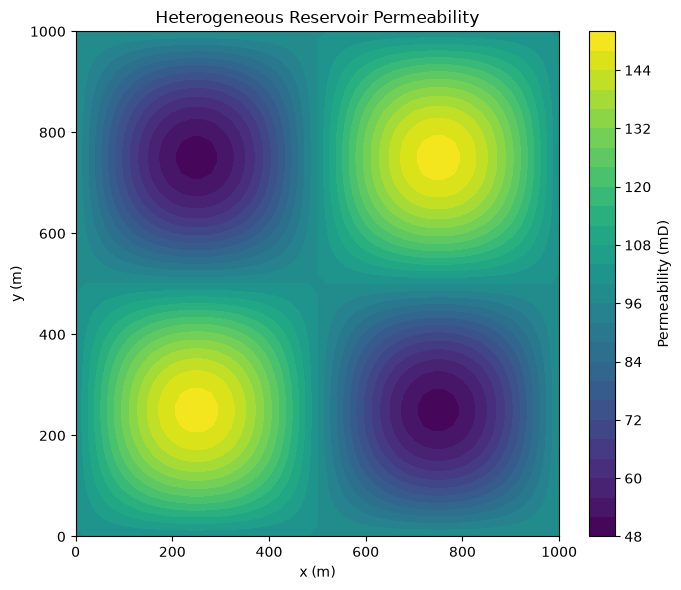

In [120]:
# ============================================================
# Visualize Heterogeneous Permeability Field
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(
    X_perm,
    Y_perm,
    k_field_mD,
    levels=30
)

plt.colorbar(label="Permeability (mD)")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Heterogeneous Reservoir Permeability")

plt.savefig(
    "../results/heterogeneous_permeability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [121]:
# ============================================================
# Stability Check for Heterogeneous Reservoir
# ============================================================

k_max_mD = k_field_mD.max()
k_max_m2 = k_max_mD * 9.869e-16

alpha_max = k_max_m2 / (
    phi
    * mu
    * ct
)

dx = x_physical[1] - x_physical[0]
dy = y_physical[1] - y_physical[0]

# Conservative explicit 2D stability limit
dt_max_heterogeneous = (
    1.0
    / (
        2.0 * alpha_max
        * (1.0 / dx**2 + 1.0 / dy**2)
    )
)

print("Heterogeneous Reservoir Stability Check")
print("----------------------------------------")
print(f"Maximum permeability: {k_max_mD:.4f} mD")
print(f"Maximum diffusivity:  {alpha_max:.6e} m²/s")
print(f"dx:                   {dx:.2f} m")
print(f"dy:                   {dy:.2f} m")
print(f"Maximum stable dt:    {dt_max_heterogeneous:.2f} s")
print(f"Maximum stable dt:    {dt_max_heterogeneous/86400:.4f} days")

Heterogeneous Reservoir Stability Check
----------------------------------------
Maximum permeability: 149.8029 mD
Maximum diffusivity:  2.464007e-01 m²/s
dx:                   20.00 m
dy:                   20.00 m
Maximum stable dt:    405.84 s
Maximum stable dt:    0.0047 days


In [122]:
# ============================================================
# Heterogeneous Reservoir Time Grid
# ============================================================

dt_heterogeneous = 300.0  # seconds

Nt_heterogeneous = int(T_physical / dt_heterogeneous) + 1

time_heterogeneous = np.arange(
    Nt_heterogeneous
) * dt_heterogeneous

# Ensure final time does not exceed the target
time_heterogeneous = time_heterogeneous[
    time_heterogeneous <= T_physical
]

Nt_heterogeneous = len(time_heterogeneous)

print("Heterogeneous Reservoir Time Grid")
print("---------------------------------")
print(f"Time step:        {dt_heterogeneous:.1f} s")
print(f"Time step:        {dt_heterogeneous/86400:.5f} days")
print(f"Number of steps:  {Nt_heterogeneous}")
print(f"Final time:       {time_heterogeneous[-1]/86400:.4f} days")

Heterogeneous Reservoir Time Grid
---------------------------------
Time step:        300.0 s
Time step:        0.00347 days
Number of steps:  8641
Final time:       30.0000 days


In [123]:
# ============================================================
# Heterogeneous Reservoir — Finite Difference Reference
# Corrected Initial Condition
# ============================================================

pressure_heterogeneous = np.zeros(
    (Nt_heterogeneous, len(x_physical), len(y_physical))
)

# Normalized spatial coordinates
X_star = X_perm / Lx_physical
Y_star = Y_perm / Ly_physical

# Initial condition
pressure_heterogeneous[0] = (
    np.sin(np.pi * X_star)
    * np.sin(np.pi * Y_star)
)

# Convert permeability field to m²
k_field_m2 = k_field_mD * 9.869e-16

# Face-centered permeability
k_x_face = 0.5 * (
    k_field_m2[:-1, :] +
    k_field_m2[1:, :]
)

k_y_face = 0.5 * (
    k_field_m2[:, :-1] +
    k_field_m2[:, 1:]
)

# Time stepping
for n in range(Nt_heterogeneous - 1):

    p = pressure_heterogeneous[n]

    # x-direction flux divergence
    flux_x = (
        k_x_face[1:, :] * (p[2:, :] - p[1:-1, :])
        - k_x_face[:-1, :] * (p[1:-1, :] - p[:-2, :])
    ) / dx**2

    # y-direction flux divergence
    flux_y = (
        k_y_face[:, 1:] * (p[:, 2:] - p[:, 1:-1])
        - k_y_face[:, :-1] * (p[:, 1:-1] - p[:, :-2])
    ) / dy**2

    pressure_heterogeneous[n + 1, 1:-1, 1:-1] = (
        p[1:-1, 1:-1]
        + dt_heterogeneous
        / (phi * mu * ct)
        * (flux_x[:, 1:-1] + flux_y[1:-1, :])
    )

    # Boundary conditions
    pressure_heterogeneous[n + 1, 0, :] = 0.0
    pressure_heterogeneous[n + 1, -1, :] = 0.0
    pressure_heterogeneous[n + 1, :, 0] = 0.0
    pressure_heterogeneous[n + 1, :, -1] = 0.0

print("Heterogeneous finite-difference simulation complete.")
print("Pressure shape:", pressure_heterogeneous.shape)
print("Initial maximum pressure:", pressure_heterogeneous[0].max())
print("Final maximum pressure:", pressure_heterogeneous[-1].max())

Heterogeneous finite-difference simulation complete.
Pressure shape: (8641, 51, 51)
Initial maximum pressure: 1.0
Final maximum pressure: 0.0002584515387726295


In [124]:
# ============================================================
# Save Heterogeneous Reservoir Reference Solution
# ============================================================

np.savez(
    "../data/reference_heterogeneous_reservoir.npz",
    x=x_physical,
    y=y_physical,
    time=time_heterogeneous,
    pressure=pressure_heterogeneous,
    permeability_mD=k_field_mD,
    permeability_m2=k_field_m2,
    phi=phi,
    mu=mu,
    ct=ct,
    dt=dt_heterogeneous
)

print("Heterogeneous reference solution saved.")
print("../data/reference_heterogeneous_reservoir.npz")

Heterogeneous reference solution saved.
../data/reference_heterogeneous_reservoir.npz


Selected time: 15.0000 days
Minimum pressure: 0.000000e+00
Maximum pressure: 1.597774e-02
Mean pressure:    6.262796e-03


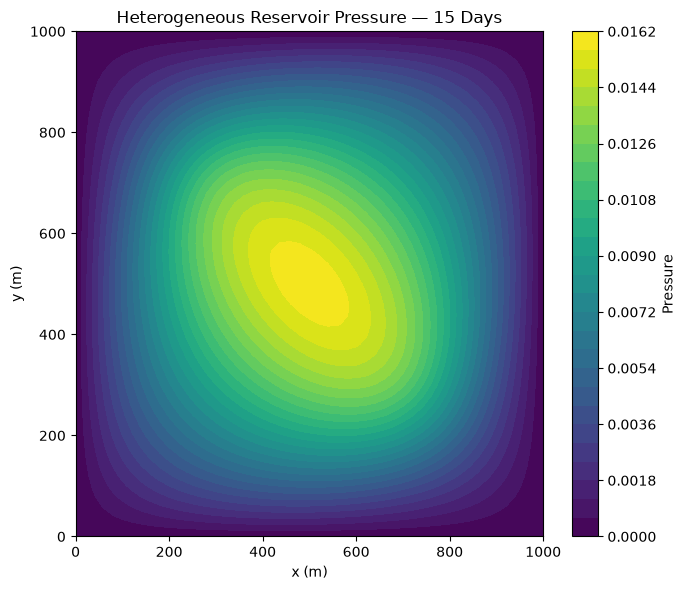

In [125]:
# ============================================================
# Heterogeneous Reference Pressure at 15 Days
# ============================================================

target_day = 15.0

time_index = np.argmin(
    np.abs(time_heterogeneous / 86400 - target_day)
)

pressure_15d = pressure_heterogeneous[time_index]

print(f"Selected time: {time_heterogeneous[time_index] / 86400:.4f} days")
print(f"Minimum pressure: {pressure_15d.min():.6e}")
print(f"Maximum pressure: {pressure_15d.max():.6e}")
print(f"Mean pressure:    {pressure_15d.mean():.6e}")

plt.figure(figsize=(7, 6))

plt.contourf(
    X_perm,
    Y_perm,
    pressure_15d,
    levels=30
)

plt.colorbar(label="Pressure")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Heterogeneous Reservoir Pressure — 15 Days")

plt.savefig(
    "../results/reference_heterogeneous_pressure_t15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [126]:
# ============================================================
# Heterogeneous Reference — Pressure Evolution
# ============================================================

check_days = [1, 5, 15, 30]

print("Heterogeneous Reservoir Pressure Evolution")
print("-------------------------------------------")

for day in check_days:

    idx = np.argmin(
        np.abs(time_heterogeneous / 86400 - day)
    )

    p_snapshot = pressure_heterogeneous[idx]

    print(
        f"{day:>2} days | "
        f"Max: {p_snapshot.max():.8f} | "
        f"Mean: {p_snapshot.mean():.8f} | "
        f"Min: {p_snapshot.min():.8f}"
    )

Heterogeneous Reservoir Pressure Evolution
-------------------------------------------
 1 days | Max: 0.75455293 | Mean: 0.29437874 | Min: 0.00000000
 5 days | Max: 0.24992458 | Mean: 0.09790620 | Min: 0.00000000
15 days | Max: 0.01597774 | Mean: 0.00626280 | Min: 0.00000000
30 days | Max: 0.00025845 | Mean: 0.00010131 | Min: 0.00000000


In [127]:
# ============================================================
# Heterogeneous PINN — Relative Permeability Function
# ============================================================

def relative_permeability(X):
    """
    Dimensionless heterogeneous permeability field.

    X[:, 0] = x*
    X[:, 1] = y*
    X[:, 2] = t*
    """

    x = X[:, 0:1]
    y = X[:, 1:2]

    k_relative = (
        1.0
        + 0.5
        * tf.sin(2.0 * np.pi * x)
        * tf.sin(2.0 * np.pi * y)
    )

    return k_relative


# Test the function
k_test = relative_permeability(X_collocation_tf)

print("Relative permeability test")
print("---------------------------")
print(f"Minimum k/k0: {tf.reduce_min(k_test).numpy():.6f}")
print(f"Maximum k/k0: {tf.reduce_max(k_test).numpy():.6f}")
print(f"Mean k/k0:    {tf.reduce_mean(k_test).numpy():.6f}")
print("Shape:", k_test.shape)

Relative permeability test
---------------------------
Minimum k/k0: 0.500345
Maximum k/k0: 1.499629
Mean k/k0:    0.998674
Shape: (10000, 1)


In [128]:
# ============================================================
# Heterogeneous PINN — Variable-Permeability PDE Residual
# ============================================================

def heterogeneous_pde_residual(model, X):

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(X)

        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(X)

            pressure_pred = model(X)

        pressure_grad = tape1.gradient(
            pressure_pred,
            X
        )

        dp_dx = pressure_grad[:, 0:1]
        dp_dy = pressure_grad[:, 1:2]
        dp_dt = pressure_grad[:, 2:3]

        # Relative permeability k/k0
        k_relative = relative_permeability(X)

        # Permeability-pressure fluxes
        k_dp_dx = k_relative * dp_dx
        k_dp_dy = k_relative * dp_dy

    # Divergence of permeability-pressure flux
    d_kdpdx_dx = tape2.gradient(
        k_dp_dx,
        X
    )[:, 0:1]

    d_kdpdy_dy = tape2.gradient(
        k_dp_dy,
        X
    )[:, 1:2]

    residual = (
        dp_dt
        - alpha_dimensionless
        * (
            d_kdpdx_dx
            + d_kdpdy_dy
        )
    )

    del tape1
    del tape2

    return residual

In [129]:
# Test heterogeneous PDE residual

heterogeneous_residual = heterogeneous_pde_residual(
    model,
    X_collocation_tf
)

print("Heterogeneous PDE residual test")
print("--------------------------------")
print("Residual shape:", heterogeneous_residual.shape)
print("First 5 residuals:")
print(heterogeneous_residual[:5].numpy())
print(
    "Residual MSE:",
    tf.reduce_mean(
        tf.square(heterogeneous_residual)
    ).numpy()
)

Heterogeneous PDE residual test
--------------------------------
Residual shape: (10000, 1)
First 5 residuals:
[[2.0968063]
 [2.4842608]
 [1.0556492]
 [2.2818756]
 [1.2147968]]
Residual MSE: 3.4551196


In [130]:
# ============================================================
# Heterogeneous PINN Loss
# ============================================================

def heterogeneous_pinn_loss(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):

    # Physics loss
    residual = heterogeneous_pde_residual(
        model,
        X_collocation
    )

    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )

    # Initial-condition loss
    pressure_initial_pred = model(
        X_initial
    )

    initial_loss = tf.reduce_mean(
        tf.square(
            pressure_initial_pred - P_initial
        )
    )

    # Boundary-condition loss
    pressure_boundary_pred = model(
        X_boundary
    )

    boundary_loss = tf.reduce_mean(
        tf.square(
            pressure_boundary_pred - P_boundary
        )
    )

    # Total loss
    total_loss = (
        physics_loss
        + initial_loss
        + boundary_loss
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

In [131]:
# ============================================================
# Heterogeneous PINN Model
# ============================================================

heterogeneous_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

heterogeneous_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Heterogeneous PINN created.")
print(
    "Trainable parameters:",
    heterogeneous_model.count_params()
)

Heterogeneous PINN created.
Trainable parameters: 7901


In [132]:
# ============================================================
# Test One Training Step — Heterogeneous PINN
# ============================================================

def heterogeneous_train_step(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):

    with tf.GradientTape() as tape:

        total_loss, physics_loss, initial_loss, boundary_loss = (
            heterogeneous_pinn_loss(
                model,
                X_collocation,
                X_initial,
                P_initial,
                X_boundary,
                P_boundary
            )
        )

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    heterogeneous_optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )


# Loss before training
loss_before = heterogeneous_pinn_loss(
    heterogeneous_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("Before training:")
print(f"Total loss:    {loss_before[0].numpy():.6f}")
print(f"Physics loss:  {loss_before[1].numpy():.6f}")
print(f"Initial loss:  {loss_before[2].numpy():.6f}")
print(f"Boundary loss: {loss_before[3].numpy():.6f}")


# One optimization step
loss_after = heterogeneous_train_step(
    heterogeneous_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("\nAfter one training step:")
print(f"Total loss:    {loss_after[0].numpy():.6f}")
print(f"Physics loss:  {loss_after[1].numpy():.6f}")
print(f"Initial loss:  {loss_after[2].numpy():.6f}")
print(f"Boundary loss: {loss_after[3].numpy():.6f}")

print(
    "\nLoss change:",
    loss_before[0].numpy() - loss_after[0].numpy()
)

Before training:
Total loss:    0.315956
Physics loss:  0.071114
Initial loss:  0.214395
Boundary loss: 0.030447

After one training step:
Total loss:    0.315956
Physics loss:  0.071114
Initial loss:  0.214395
Boundary loss: 0.030447

Loss change: 0.0


In [133]:
# ============================================================
# Reset Heterogeneous PINN Optimizer
# ============================================================

heterogeneous_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("New optimizer created.")

New optimizer created.


In [134]:
# ============================================================
# Fresh Heterogeneous PINN + One-Step Test
# ============================================================

heterogeneous_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

heterogeneous_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

# Loss before training
loss_before = heterogeneous_pinn_loss(
    heterogeneous_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

# One optimization step
loss_after = heterogeneous_train_step(
    heterogeneous_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

print("Before training:")
print(f"Total loss:     {loss_before[0].numpy():.6f}")
print(f"Physics loss:   {loss_before[1].numpy():.6f}")
print(f"Initial loss:   {loss_before[2].numpy():.6f}")
print(f"Boundary loss:  {loss_before[3].numpy():.6f}")

print("\nAfter one training step:")
print(f"Total loss:     {loss_after[0].numpy():.6f}")
print(f"Physics loss:   {loss_after[1].numpy():.6f}")
print(f"Initial loss:   {loss_after[2].numpy():.6f}")
print(f"Boundary loss:  {loss_after[3].numpy():.6f}")

print(
    "\nLoss change:",
    loss_before[0].numpy() - loss_after[0].numpy()
)

Before training:
Total loss:     0.346091
Physics loss:   0.058617
Initial loss:   0.278052
Boundary loss:  0.009422

After one training step:
Total loss:     0.346091
Physics loss:   0.058617
Initial loss:   0.278052
Boundary loss:  0.009422

Loss change: 0.0


In [135]:
# ============================================================
# Diagnose Heterogeneous PINN Gradients
# ============================================================

with tf.GradientTape() as tape:

    test_loss, test_physics, test_initial, test_boundary = (
        heterogeneous_pinn_loss(
            heterogeneous_model,
            X_collocation_tf,
            X_initial_tf,
            P_initial_tf,
            X_boundary_tf,
            P_boundary_tf
        )
    )

gradients = tape.gradient(
    test_loss,
    heterogeneous_model.trainable_variables
)

print("Gradient diagnostics")
print("--------------------")

for i, grad in enumerate(gradients):

    if grad is None:
        print(f"Layer {i}: None")
    else:
        print(
            f"Layer {i}: "
            f"shape={grad.shape}, "
            f"mean={tf.reduce_mean(grad).numpy():.6e}, "
            f"max_abs={tf.reduce_max(tf.abs(grad)).numpy():.6e}"
        )

Gradient diagnostics
--------------------
Layer 0: shape=(3, 50), mean=1.916190e-03, max_abs=1.370444e-01
Layer 1: shape=(50,), mean=-8.257422e-03, max_abs=1.460312e-01
Layer 2: shape=(50, 50), mean=4.665751e-05, max_abs=7.703208e-02
Layer 3: shape=(50,), mean=7.955677e-04, max_abs=1.652618e-01
Layer 4: shape=(50, 50), mean=1.020279e-04, max_abs=6.951684e-02
Layer 5: shape=(50,), mean=9.273334e-03, max_abs=1.608062e-01
Layer 6: shape=(50, 50), mean=6.099097e-05, max_abs=4.929524e-02
Layer 7: shape=(50,), mean=-6.079751e-03, max_abs=1.060588e-01
Layer 8: shape=(50, 1), mean=9.054148e-03, max_abs=1.764120e-01
Layer 9: shape=(1,), mean=-3.112288e-01, max_abs=3.112288e-01


In [136]:
# ============================================================
# Verify Actual Model Weight Update
# ============================================================

# Save the weights before training
weights_before = [
    w.numpy().copy()
    for w in heterogeneous_model.trainable_variables
]

# Perform one training step
heterogeneous_train_step(
    heterogeneous_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

# Compare weights after training
weight_changes = []

for before, after in zip(
    weights_before,
    heterogeneous_model.trainable_variables
):
    change = np.max(
        np.abs(before - after.numpy())
    )
    weight_changes.append(change)

print("Weight update diagnostics")
print("-------------------------")

for i, change in enumerate(weight_changes):
    print(f"Layer {i}: max weight change = {change:.8e}")

print(
    "\nLargest weight change:",
    max(weight_changes)
)

Weight update diagnostics
-------------------------
Layer 0: max weight change = 1.00115687e-03
Layer 1: max weight change = 9.94229806e-04
Layer 2: max weight change = 1.00128353e-03
Layer 3: max weight change = 1.00041437e-03
Layer 4: max weight change = 1.00111961e-03
Layer 5: max weight change = 1.00069097e-03
Layer 6: max weight change = 1.00116991e-03
Layer 7: max weight change = 9.12866089e-04
Layer 8: max weight change = 9.94905829e-04
Layer 9: max weight change = 8.95756413e-04

Largest weight change: 0.0010012835


In [137]:
# ============================================================
# Train Heterogeneous PINN
# ============================================================

heterogeneous_epochs = 5000

heterogeneous_loss_history = []
heterogeneous_physics_history = []
heterogeneous_initial_history = []
heterogeneous_boundary_history = []

for epoch in range(heterogeneous_epochs):

    total_loss, physics_loss, initial_loss, boundary_loss = (
        heterogeneous_train_step(
            heterogeneous_model,
            X_collocation_tf,
            X_initial_tf,
            P_initial_tf,
            X_boundary_tf,
            P_boundary_tf
        )
    )

    heterogeneous_loss_history.append(
        float(total_loss.numpy())
    )

    heterogeneous_physics_history.append(
        float(physics_loss.numpy())
    )

    heterogeneous_initial_history.append(
        float(initial_loss.numpy())
    )

    heterogeneous_boundary_history.append(
        float(boundary_loss.numpy())
    )

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total {total_loss.numpy():.6f} | "
            f"Physics {physics_loss.numpy():.6f} | "
            f"Initial {initial_loss.numpy():.6f} | "
            f"Boundary {boundary_loss.numpy():.6f}"
        )

Epoch    0 | Total 0.172019 | Physics 0.021237 | Initial 0.117525 | Boundary 0.033257
Epoch  500 | Total 0.061018 | Physics 0.024049 | Initial 0.032210 | Boundary 0.004759
Epoch 1000 | Total 0.012356 | Physics 0.008725 | Initial 0.002464 | Boundary 0.001167
Epoch 1500 | Total 0.005141 | Physics 0.003738 | Initial 0.000863 | Boundary 0.000540
Epoch 2000 | Total 0.005456 | Physics 0.004004 | Initial 0.000829 | Boundary 0.000623
Epoch 2500 | Total 0.002266 | Physics 0.001262 | Initial 0.000688 | Boundary 0.000316
Epoch 3000 | Total 0.001789 | Physics 0.000907 | Initial 0.000632 | Boundary 0.000249
Epoch 3500 | Total 0.001616 | Physics 0.000814 | Initial 0.000580 | Boundary 0.000222
Epoch 4000 | Total 0.001297 | Physics 0.000589 | Initial 0.000543 | Boundary 0.000164
Epoch 4500 | Total 0.001101 | Physics 0.000454 | Initial 0.000500 | Boundary 0.000148


In [138]:
# ============================================================
# Validate Heterogeneous PINN
# ============================================================

N_validation_heterogeneous = 10000

rng = np.random.default_rng(42)

time_indices = rng.integers(
    0,
    len(time_heterogeneous),
    N_validation_heterogeneous
)

x_indices = rng.integers(
    0,
    len(x_physical),
    N_validation_heterogeneous
)

y_indices = rng.integers(
    0,
    len(y_physical),
    N_validation_heterogeneous
)

# Normalize coordinates for the PINN
X_validation_heterogeneous = np.column_stack((
    x_physical[x_indices] / Lx_physical,
    y_physical[y_indices] / Ly_physical,
    time_heterogeneous[time_indices] / T_physical
))

# Independent finite-difference reference
P_reference_heterogeneous = (
    pressure_heterogeneous[
        time_indices,
        x_indices,
        y_indices
    ]
    .reshape(-1, 1)
)

# PINN prediction
P_prediction_heterogeneous = heterogeneous_model(
    tf.convert_to_tensor(
        X_validation_heterogeneous,
        dtype=tf.float32
    )
).numpy()

# Errors
absolute_error = np.abs(
    P_prediction_heterogeneous
    - P_reference_heterogeneous
)

mae_heterogeneous = np.mean(
    absolute_error
)

rmse_heterogeneous = np.sqrt(
    np.mean(
        (
            P_prediction_heterogeneous
            - P_reference_heterogeneous
        ) ** 2
    )
)

max_error_heterogeneous = np.max(
    absolute_error
)

print("Heterogeneous PINN Validation")
print("-----------------------------")
print(f"Validation points: {N_validation_heterogeneous}")
print(f"MAE:                {mae_heterogeneous:.8f}")
print(f"RMSE:               {rmse_heterogeneous:.8f}")
print(f"Maximum error:      {max_error_heterogeneous:.8f}")

Heterogeneous PINN Validation
-----------------------------
Validation points: 10000
MAE:                0.00847831
RMSE:               0.00979247
Maximum error:      0.05201638


In [139]:
# ============================================================
# Heterogeneous PINN vs Reference — 15 Days
# ============================================================

target_day = 15.0

time_index = np.argmin(
    np.abs(time_heterogeneous / 86400 - target_day)
)

# Reference pressure at 15 days
pressure_reference_15d = pressure_heterogeneous[time_index]

# Create full 51 x 51 grid for PINN prediction
X_grid_15d = np.column_stack((
    X_perm.ravel() / Lx_physical,
    Y_perm.ravel() / Ly_physical,
    np.full(
        X_perm.size,
        time_heterogeneous[time_index] / T_physical
    )
))

# PINN prediction
pressure_prediction_15d = heterogeneous_model(
    tf.convert_to_tensor(
        X_grid_15d,
        dtype=tf.float32
    )
).numpy().reshape(X_perm.shape)

# Absolute error
error_15d = np.abs(
    pressure_prediction_15d
    - pressure_reference_15d
)

print("Heterogeneous PINN — 15 Day Validation")
print("---------------------------------------")
print(
    f"Time:                 "
    f"{time_heterogeneous[time_index]/86400:.4f} days"
)
print(
    f"Reference max:        "
    f"{pressure_reference_15d.max():.8f}"
)
print(
    f"PINN max:             "
    f"{pressure_prediction_15d.max():.8f}"
)
print(
    f"PINN min:             "
    f"{pressure_prediction_15d.min():.8f}"
)
print(
    f"Mean absolute error:  "
    f"{error_15d.mean():.8f}"
)
print(
    f"Maximum error:        "
    f"{error_15d.max():.8f}"
)

Heterogeneous PINN — 15 Day Validation
---------------------------------------
Time:                 15.0000 days
Reference max:        0.01597774
PINN max:             0.00785463
PINN min:             -0.02353706
Mean absolute error:  0.00958302
Maximum error:        0.02353706


In [140]:
# ============================================================
# Heterogeneous PINN — Boundary Diagnostic at 15 Days
# ============================================================

# Extract the four boundaries
boundary_left = pressure_prediction_15d[0, :]
boundary_right = pressure_prediction_15d[-1, :]
boundary_bottom = pressure_prediction_15d[:, 0]
boundary_top = pressure_prediction_15d[:, -1]

# Combine all boundary values
boundary_values = np.concatenate([
    boundary_left,
    boundary_right,
    boundary_bottom,
    boundary_top
])

print("Heterogeneous PINN — Boundary Diagnostic")
print("-----------------------------------------")
print(
    f"Mean absolute boundary pressure: "
    f"{np.mean(np.abs(boundary_values)):.8f}"
)
print(
    f"Maximum absolute boundary pressure: "
    f"{np.max(np.abs(boundary_values)):.8f}"
)
print(
    f"Minimum boundary pressure: "
    f"{boundary_values.min():.8f}"
)
print(
    f"Maximum boundary pressure: "
    f"{boundary_values.max():.8f}"
)

Heterogeneous PINN — Boundary Diagnostic
-----------------------------------------
Mean absolute boundary pressure: 0.01054514
Maximum absolute boundary pressure: 0.02353706
Minimum boundary pressure: -0.02353706
Maximum boundary pressure: -0.00321509


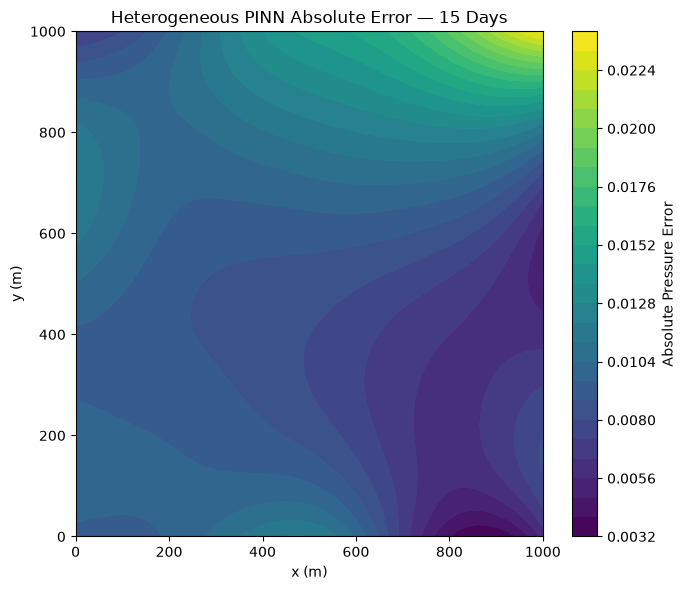

Figure saved to ../results/heterogeneous_pinn_absolute_error_t15.png


In [141]:
# ============================================================
# Heterogeneous PINN — Absolute Error at 15 Days
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(
    X_perm,
    Y_perm,
    error_15d,
    levels=30
)

plt.colorbar(label="Absolute Pressure Error")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Heterogeneous PINN Absolute Error — 15 Days")

plt.tight_layout()

plt.savefig(
    "../results/heterogeneous_pinn_absolute_error_t15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved to "
    "../results/heterogeneous_pinn_absolute_error_t15.png"
)

In [142]:
# ============================================================
# Boundary-Weighted Heterogeneous PINN Loss
# ============================================================

boundary_weight_heterogeneous = 5.0

def heterogeneous_pinn_loss_weighted(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):

    # Physics loss
    residual = heterogeneous_pde_residual(
        model,
        X_collocation
    )

    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )

    # Initial-condition loss
    pressure_initial_pred = model(
        X_initial
    )

    initial_loss = tf.reduce_mean(
        tf.square(
            pressure_initial_pred - P_initial
        )
    )

    # Boundary-condition loss
    pressure_boundary_pred = model(
        X_boundary
    )

    boundary_loss = tf.reduce_mean(
        tf.square(
            pressure_boundary_pred - P_boundary
        )
    )

    # Weighted total loss
    total_loss = (
        physics_loss
        + initial_loss
        + boundary_weight_heterogeneous * boundary_loss
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

print(
    f"Boundary loss weight: "
    f"{boundary_weight_heterogeneous}"
)

Boundary loss weight: 5.0


In [143]:
# ============================================================
# Fresh Boundary-Weighted Heterogeneous PINN
# ============================================================

heterogeneous_weighted_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

heterogeneous_weighted_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Fresh boundary-weighted model created.")
print(
    "Trainable parameters:",
    heterogeneous_weighted_model.count_params()
)

Fresh boundary-weighted model created.
Trainable parameters: 7901


In [144]:
# ============================================================
# One-Step Test — Boundary-Weighted Heterogeneous PINN
# ============================================================

def heterogeneous_weighted_train_step(
    model,
    X_collocation,
    X_initial,
    P_initial,
    X_boundary,
    P_boundary
):

    with tf.GradientTape() as tape:

        total_loss, physics_loss, initial_loss, boundary_loss = (
            heterogeneous_pinn_loss_weighted(
                model,
                X_collocation,
                X_initial,
                P_initial,
                X_boundary,
                P_boundary
            )
        )

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    heterogeneous_weighted_optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )


# Get numerical loss before training
loss_before = heterogeneous_pinn_loss_weighted(
    heterogeneous_weighted_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

loss_before_value = loss_before[0].numpy()

# One optimization step
loss_after = heterogeneous_weighted_train_step(
    heterogeneous_weighted_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

loss_after_value = loss_after[0].numpy()

print("Boundary-Weighted One-Step Test")
print("--------------------------------")
print(f"Before: {loss_before_value:.6f}")
print(f"After:  {loss_after_value:.6f}")
print(f"Change: {loss_before_value - loss_after_value:.6f}")

Boundary-Weighted One-Step Test
--------------------------------
Before: 1.258485
After:  1.258485
Change: 0.000000


In [145]:
# ============================================================
# Verify Boundary-Weighted Model Weight Update
# ============================================================

# Save weights before the update
weights_before = [
    w.numpy().copy()
    for w in heterogeneous_weighted_model.trainable_variables
]

# Perform one training step
heterogeneous_weighted_train_step(
    heterogeneous_weighted_model,
    X_collocation_tf,
    X_initial_tf,
    P_initial_tf,
    X_boundary_tf,
    P_boundary_tf
)

# Measure actual changes
weight_changes = []

for before, after in zip(
    weights_before,
    heterogeneous_weighted_model.trainable_variables
):
    change = np.max(
        np.abs(before - after.numpy())
    )
    weight_changes.append(change)

print("Boundary-Weighted Model Update")
print("------------------------------")

for i, change in enumerate(weight_changes):
    print(
        f"Layer {i}: "
        f"max weight change = {change:.8e}"
    )

print(
    "\nLargest weight change:",
    max(weight_changes)
)

Boundary-Weighted Model Update
------------------------------
Layer 0: max weight change = 1.00122392e-03
Layer 1: max weight change = 1.00103533e-03
Layer 2: max weight change = 1.00129843e-03
Layer 3: max weight change = 1.00060692e-03
Layer 4: max weight change = 1.00132823e-03
Layer 5: max weight change = 9.94235743e-04
Layer 6: max weight change = 1.00131333e-03
Layer 7: max weight change = 9.72585753e-04
Layer 8: max weight change = 1.00082159e-03
Layer 9: max weight change = 9.49069741e-04

Largest weight change: 0.0010013282


In [146]:
# ============================================================
# Train Boundary-Weighted Heterogeneous PINN
# ============================================================

# Fresh model
heterogeneous_weighted_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(1)
])

# Fresh optimizer
heterogeneous_weighted_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

weighted_epochs = 5000

weighted_loss_history = []
weighted_physics_history = []
weighted_initial_history = []
weighted_boundary_history = []

for epoch in range(weighted_epochs):

    (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    ) = heterogeneous_weighted_train_step(
        heterogeneous_weighted_model,
        X_collocation_tf,
        X_initial_tf,
        P_initial_tf,
        X_boundary_tf,
        P_boundary_tf
    )

    weighted_loss_history.append(
        float(total_loss.numpy())
    )

    weighted_physics_history.append(
        float(physics_loss.numpy())
    )

    weighted_initial_history.append(
        float(initial_loss.numpy())
    )

    weighted_boundary_history.append(
        float(boundary_loss.numpy())
    )

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total {total_loss.numpy():.6f} | "
            f"Physics {physics_loss.numpy():.6f} | "
            f"Initial {initial_loss.numpy():.6f} | "
            f"Boundary {boundary_loss.numpy():.6f}"
        )

Epoch    0 | Total 0.423135 | Physics 0.077102 | Initial 0.239601 | Boundary 0.021286
Epoch  500 | Total 0.082908 | Physics 0.030337 | Initial 0.041932 | Boundary 0.002128
Epoch 1000 | Total 0.010304 | Physics 0.007223 | Initial 0.001501 | Boundary 0.000316
Epoch 1500 | Total 0.003533 | Physics 0.002157 | Initial 0.000684 | Boundary 0.000138
Epoch 2000 | Total 0.002390 | Physics 0.001317 | Initial 0.000609 | Boundary 0.000093
Epoch 2500 | Total 0.001837 | Physics 0.000950 | Initial 0.000589 | Boundary 0.000060
Epoch 3000 | Total 0.001383 | Physics 0.000659 | Initial 0.000496 | Boundary 0.000045
Epoch 3500 | Total 0.001138 | Physics 0.000518 | Initial 0.000451 | Boundary 0.000034
Epoch 4000 | Total 0.000987 | Physics 0.000419 | Initial 0.000421 | Boundary 0.000029
Epoch 4500 | Total 0.000775 | Physics 0.000306 | Initial 0.000387 | Boundary 0.000017


In [147]:
# ============================================================
# Validate Boundary-Weighted Heterogeneous PINN
# ============================================================

P_prediction_weighted = heterogeneous_weighted_model(
    tf.convert_to_tensor(
        X_validation_heterogeneous,
        dtype=tf.float32
    )
).numpy()

weighted_absolute_error = np.abs(
    P_prediction_weighted
    - P_reference_heterogeneous
)

weighted_mae = np.mean(
    weighted_absolute_error
)

weighted_rmse = np.sqrt(
    np.mean(
        (
            P_prediction_weighted
            - P_reference_heterogeneous
        ) ** 2
    )
)

weighted_max_error = np.max(
    weighted_absolute_error
)

print("Boundary-Weighted Heterogeneous PINN")
print("------------------------------------")
print(f"MAE:           {weighted_mae:.8f}")
print(f"RMSE:          {weighted_rmse:.8f}")
print(f"Maximum error: {weighted_max_error:.8f}")

Boundary-Weighted Heterogeneous PINN
------------------------------------
MAE:           0.00143093
RMSE:          0.00253713
Maximum error: 0.04873830


In [148]:
# ============================================================
# Boundary-Weighted PINN — 15 Day Diagnostic
# ============================================================

pressure_weighted_15d = heterogeneous_weighted_model(
    tf.convert_to_tensor(
        X_grid_15d,
        dtype=tf.float32
    )
).numpy().reshape(X_perm.shape)

weighted_error_15d = np.abs(
    pressure_weighted_15d
    - pressure_reference_15d
)

print("Boundary-Weighted Heterogeneous PINN — 15 Days")
print("-----------------------------------------------")
print(f"Reference max:       {pressure_reference_15d.max():.8f}")
print(f"PINN max:             {pressure_weighted_15d.max():.8f}")
print(f"PINN min:             {pressure_weighted_15d.min():.8f}")
print(f"Mean absolute error: {weighted_error_15d.mean():.8f}")
print(f"Maximum error:       {weighted_error_15d.max():.8f}")

Boundary-Weighted Heterogeneous PINN — 15 Days
-----------------------------------------------
Reference max:       0.01597774
PINN max:             0.01570452
PINN min:             -0.00450380
Mean absolute error: 0.00078528
Maximum error:       0.00450380


In [149]:
# ============================================================
# Boundary-Weighted Heterogeneous PINN
# Time-Dependent Validation
# ============================================================

check_days = [1, 5, 15, 30]

print("Boundary-Weighted Heterogeneous PINN")
print("Time-Dependent Validation")
print("--------------------------------------")

for day in check_days:

    idx = np.argmin(
        np.abs(time_heterogeneous / 86400 - day)
    )

    reference_snapshot = pressure_heterogeneous[idx]

    X_snapshot = np.column_stack((
        X_perm.ravel() / Lx_physical,
        Y_perm.ravel() / Ly_physical,
        np.full(
            X_perm.size,
            time_heterogeneous[idx] / T_physical
        )
    ))

    prediction_snapshot = (
        heterogeneous_weighted_model(
            tf.convert_to_tensor(
                X_snapshot,
                dtype=tf.float32
            )
        )
        .numpy()
        .reshape(X_perm.shape)
    )

    error = np.abs(
        prediction_snapshot - reference_snapshot
    )

    print(
        f"{day:>2} days | "
        f"Reference max: {reference_snapshot.max():.8f} | "
        f"PINN max: {prediction_snapshot.max():.8f} | "
        f"MAE: {error.mean():.8f} | "
        f"Max error: {error.max():.8f}"
    )

Boundary-Weighted Heterogeneous PINN
Time-Dependent Validation
--------------------------------------
 1 days | Reference max: 0.75455293 | PINN max: 0.75166297 | MAE: 0.00365554 | Max error: 0.02144545
 5 days | Reference max: 0.24992458 | PINN max: 0.25175574 | MAE: 0.00259366 | Max error: 0.01806655
15 days | Reference max: 0.01597774 | PINN max: 0.01570452 | MAE: 0.00078528 | Max error: 0.00450380
30 days | Reference max: 0.00025845 | PINN max: 0.00189218 | MAE: 0.00070430 | Max error: 0.00687979


In [150]:
# ============================================================
# Save Best Heterogeneous PINN
# ============================================================

heterogeneous_weighted_model.save(
    "../models/pinn_heterogeneous_boundary_weighted.keras"
)

# Save training history
np.savez(
    "../results/heterogeneous_boundary_weighted_training_history.npz",
    total_loss=np.array(weighted_loss_history),
    physics_loss=np.array(weighted_physics_history),
    initial_loss=np.array(weighted_initial_history),
    boundary_loss=np.array(weighted_boundary_history)
)

print("Best heterogeneous PINN saved.")
print("../models/pinn_heterogeneous_boundary_weighted.keras")

print("\nTraining history saved.")
print(
    "../results/"
    "heterogeneous_boundary_weighted_training_history.npz"
)

Best heterogeneous PINN saved.
../models/pinn_heterogeneous_boundary_weighted.keras

Training history saved.
../results/heterogeneous_boundary_weighted_training_history.npz


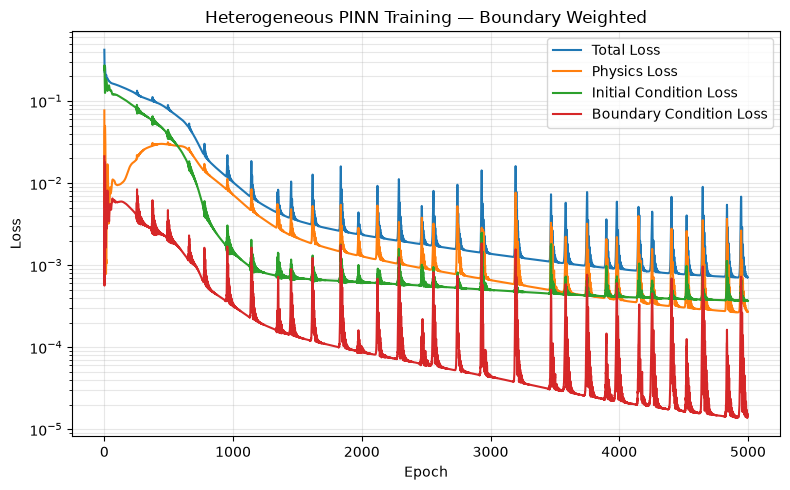

Figure saved to ../results/heterogeneous_pinn_training_loss.png


In [151]:
# ============================================================
# Heterogeneous PINN — Training Loss Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.semilogy(
    weighted_loss_history,
    label="Total Loss"
)

plt.semilogy(
    weighted_physics_history,
    label="Physics Loss"
)

plt.semilogy(
    weighted_initial_history,
    label="Initial Condition Loss"
)

plt.semilogy(
    weighted_boundary_history,
    label="Boundary Condition Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Heterogeneous PINN Training — Boundary Weighted"
)

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/heterogeneous_pinn_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved to "
    "../results/heterogeneous_pinn_training_loss.png"
)

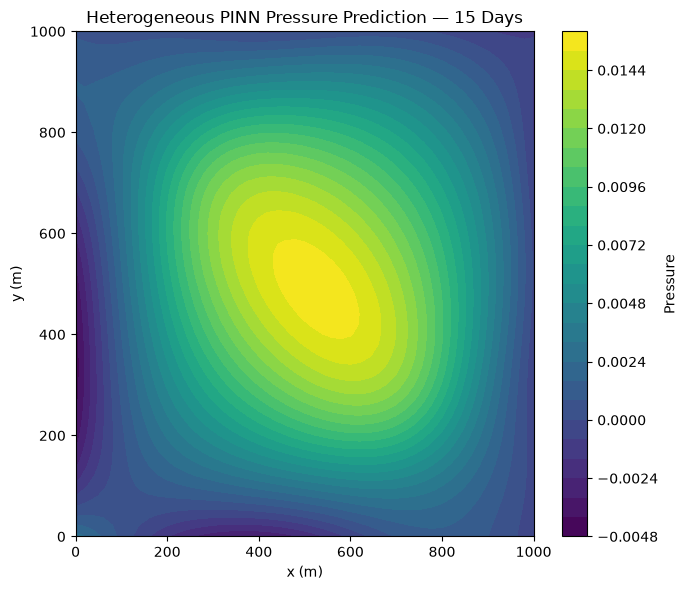

Figure saved to ../results/heterogeneous_pinn_pressure_t15.png


In [152]:
# ============================================================
# Save Heterogeneous PINN Pressure Prediction — 15 Days
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(
    X_perm,
    Y_perm,
    pressure_weighted_15d,
    levels=30
)

plt.colorbar(label="Pressure")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(
    "Heterogeneous PINN Pressure Prediction — 15 Days"
)

plt.tight_layout()

plt.savefig(
    "../results/heterogeneous_pinn_pressure_t15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved to "
    "../results/heterogeneous_pinn_pressure_t15.png"
)

In [153]:
# ============================================================
# Save Heterogeneous PINN Validation Metrics
# ============================================================

heterogeneous_validation_results = pd.DataFrame({
    "time_days": [1, 5, 15, 30],
    "reference_max_pressure": [
        0.75455293,
        0.24992458,
        0.01597774,
        0.00025845
    ],
    "pinn_max_pressure": [
        0.75166297,
        0.25175574,
        0.01570452,
        0.00189218
    ],
    "mae": [
        0.00365554,
        0.00259366,
        0.00078528,
        0.00070430
    ],
    "max_error": [
        0.02144545,
        0.01806655,
        0.00450380,
        0.00687979
    ]
})

heterogeneous_validation_results.to_csv(
    "../results/heterogeneous_pinn_validation.csv",
    index=False
)

print(
    "Validation results saved to "
    "../results/heterogeneous_pinn_validation.csv"
)

heterogeneous_validation_results

Validation results saved to ../results/heterogeneous_pinn_validation.csv


,time_days,reference_max_pressure,pinn_max_pressure,mae,max_error
0,1,0.754553,0.751663,0.003656,0.021445
1,5,0.249925,0.251756,0.002594,0.018067
2,15,0.015978,0.015705,0.000785,0.004504
3,30,0.000258,0.001892,0.000704,0.006880
